# Superfícies parâmetro × tempo — sistema aberto

Este notebook plota os resultados que realmente permitem superfície no conjunto gerado por `run_lista_simulacoes_open_system.py`.

Aqui a superfície é:

\[
    x = t, \qquad y = \zeta, T \text{ ou } \omega, \qquad z = \text{métrica}(t, y).
\]

Ou seja: **não** é a superfície da função de Wigner no espaço de fase \(W(x,p)\). É a superfície temporal da métrica salva em `var_aberto.npy`.

O notebook usa apenas os blocos com varredura completa:

- `only_dephasing`;
- `only_cavity_damping`.

O bloco `specific_parameters` não entra aqui porque ele tem apenas pontos específicos, não uma malha de parâmetros.

In [1]:
import os
import re
import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (10.5, 6.5),
    "axes.grid": False,
    "font.size": 12,
})

## Configuração

In [2]:
BASE = "results/lista_simulacoes_open_system"
ROOT = None

# Se True, salva cada figura em ROOT/figures_surfaces_parameter_time.
SAVE_FIGURES = True
SAVE_PNG = True
SAVE_PDF = True
DPI = 220
FIG_DIR_NAME = "figures_surfaces_parameter_time"

# Superfície principal por mapa de cor: métrica(t, parâmetro).
PLOT_METRIC_SURFACE = True

# Superfície da diferença contra o acoplamento constante aberto:
# var_aberto(t, parâmetro) - const_aberto(t).
PLOT_DIFFERENCE_SURFACE = True

# 3D real com plot_surface. Pode ficar pesado se rodar todos os casos.
PLOT_3D_SURFACE = False

CMAP_METRIC = "viridis"
CMAP_DIFF = "coolwarm"

## Localizar pasta de resultados

In [3]:
def _root_key(path):
    name = os.path.basename(path)
    m = re.search(r"open_system_sims(\d+)$", name)
    if m:
        return int(m.group(1))
    return -1


def latest_root(base=BASE):
    folders = glob.glob(os.path.join(base, "open_system_sims*"))
    folders = [f for f in folders if os.path.isdir(f)]
    if not folders:
        raise FileNotFoundError(
            "Não encontrei resultados. Rode primeiro: python run_lista_simulacoes_open_system.py"
        )
    return sorted(folders, key=_root_key)[-1]


if ROOT is None:
    ROOT = latest_root()

FIG_DIR = os.path.join(ROOT, FIG_DIR_NAME)
os.makedirs(FIG_DIR, exist_ok=True)

print("ROOT =", ROOT)
print("Figuras em:", FIG_DIR)

ROOT = results/lista_simulacoes_open_system/open_system_sims1
Figuras em: results/lista_simulacoes_open_system/open_system_sims1/figures_surfaces_parameter_time


## Tabela de casos disponíveis

In [4]:
case_map_path = os.path.join(ROOT, "case_map.csv")

if os.path.exists(case_map_path):
    case_map = pd.read_csv(case_map_path)
else:
    case_map = pd.DataFrame()
    print("Aviso: não achei case_map.csv. O notebook ainda pode funcionar usando as pastas dos casos.")

if len(case_map):
    surface_cases = case_map[
        case_map["block"].isin(["only_dephasing", "only_cavity_damping"])
        & (case_map["n_scan"] > 2)
    ].copy()
    display(surface_cases)
else:
    surface_cases = pd.DataFrame()
    print("Sem case_map para mostrar.")

,case_id,block,resource,state_kind,coupling,scan_name,scan_display_name,n_scan,tmax,metric_label,fixed_args,note
0,only_dephasing_wigner_gauss_zeta,only_dephasing,wigner,wigner,gauss,epsilon,zeta,250,15.0,N_W(t),"{""T"": 7.5, ""sigma"": -1.0}",Wigner: gaussian varying width; plotting av in...
1,only_dephasing_wigner_gauss_T,only_dephasing,wigner,wigner,gauss,T,T,100,15.0,N_W(t),"{""epsilon"": 2.4, ""sigma"": -1.0}",Wigner: gaussian varying peak time; plotting a...
2,only_dephasing_wigner_cos_omega,only_dephasing,wigner,wigner,cos,w,omega,100,15.0,N_W(t),"{""phi"": 0.0}",Wigner: cosine varying frequency; plotting min...
3,only_dephasing_coherence_gauss_zeta,only_dephasing,coherence,coherence,gauss,epsilon,zeta,100,50.0,C_q(t),"{""T"": 25.0, ""sigma"": -1.0}",coherence: gaussian varying width; plotting av...
4,only_dephasing_coherence_gauss_T,only_dephasing,coherence,coherence,gauss,T,T,100,50.0,C_q(t),"{""epsilon"": 8.0, ""sigma"": -1.0}",coherence: gaussian varying peak time; plottin...
5,only_dephasing_coherence_cos_omega,only_dephasing,coherence,coherence,cos,w,omega,200,50.0,C_q(t),"{""phi"": 0.0}",coherence: cosine varying frequency; plotting ...
6,only_dephasing_magic_gauss_zeta,only_dephasing,magic,magic,gauss,epsilon,zeta,100,50.0,M_2(t),"{""T"": 25.0, ""sigma"": -1.0}",magic: gaussian varying width; plotting av ind...
7,only_dephasing_magic_gauss_T,only_dephasing,magic,magic,gauss,T,T,100,50.0,M_2(t),"{""epsilon"": 8.0, ""sigma"": -1.0}",magic: gaussian varying peak time; plotting av...
8,only_dephasing_magic_cos_omega,only_dephasing,magic,magic,cos,w,omega,200,50.0,M_2(t),"{""phi"": 0.0}",magic: cosine varying frequency; plotting min ...
9,only_dephasing_entanglement_gauss_zeta,only_dephasing,entanglement,entanglement,gauss,epsilon,zeta,100,50.0,E_N(t),"{""T"": 25.0, ""sigma"": -1.0}",entanglement: gaussian varying width; plotting...


## Funções auxiliares

As células abaixo só chamam `plot_surface_case(...)`.

In [5]:
def case_dir(case_id):
    return os.path.join(ROOT, case_id)


def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _edges_from_centers(x):
    x = np.asarray(x, dtype=float)
    if x.size == 1:
        dx = 1.0
        return np.array([x[0] - dx / 2, x[0] + dx / 2], dtype=float)
    dx = np.diff(x)
    edges = np.empty(x.size + 1, dtype=float)
    edges[1:-1] = x[:-1] + dx / 2
    edges[0] = x[0] - dx[0] / 2
    edges[-1] = x[-1] + dx[-1] / 2
    return edges


def metric_label_from_case(case_id, meta=None):
    if meta is not None and "metric_label" in meta:
        return meta["metric_label"]
    if "wigner" in case_id:
        return r"$N_W(t)$"
    if "coherence" in case_id:
        return r"$C(t)$"
    if "magic" in case_id:
        return r"$M_2(t)$"
    if "entanglement" in case_id:
        return r"$E_N(t)$"
    return "metric"


def parameter_label_from_case(case_id, meta=None):
    scan_display = None
    if meta is not None:
        scan_display = meta.get("scan_display_name")

    if scan_display is None:
        if case_id.endswith("_zeta"):
            scan_display = "zeta"
        elif case_id.endswith("_T"):
            scan_display = "T"
        elif case_id.endswith("_omega"):
            scan_display = "omega"

    if scan_display == "zeta":
        return r"$\zeta$"
    if scan_display == "T":
        return r"$T$"
    if scan_display == "omega":
        return r"$\omega$"
    return str(scan_display)


def pretty_title(case_id):
    parts = case_id.split("_")
    block = " ".join(parts[:2])
    if case_id.startswith("only_cavity_damping"):
        block = "only cavity damping"
        rest = case_id.replace("only_cavity_damping_", "")
    else:
        rest = case_id.replace("only_dephasing_", "")

    rest = rest.replace("_gauss_zeta", " | Gaussian varying zeta")
    rest = rest.replace("_gauss_T", " | Gaussian varying T")
    rest = rest.replace("_cos_omega", " | Cosine varying omega")
    rest = rest.replace("wigner", "Wigner negativity")
    rest = rest.replace("coherence", "Coherence")
    rest = rest.replace("magic", "Magic")
    rest = rest.replace("entanglement", "Entanglement")

    return block.replace("_", " ").title() + " | " + rest


def safe_filename(text):
    text = text.replace("/", "_").replace("\\", "_")
    text = re.sub(r"[^a-zA-Z0-9_\-\.]+", "_", text)
    text = re.sub(r"_+", "_", text)
    return text.strip("_")


def save_current_figure(fig, case_id, suffix):
    if not SAVE_FIGURES:
        return
    base = os.path.join(FIG_DIR, safe_filename(f"{case_id}_{suffix}"))
    if SAVE_PNG:
        fig.savefig(base + ".png", dpi=DPI, bbox_inches="tight")
    if SAVE_PDF:
        fig.savefig(base + ".pdf", bbox_inches="tight")


def load_surface_case(case_id):
    folder = case_dir(case_id)
    if not os.path.isdir(folder):
        print(f"[faltando] pasta não existe: {folder}")
        return None

    t_path = os.path.join(folder, "t.npy")
    scan_path = os.path.join(folder, "scan_values.npy")
    var_path = os.path.join(folder, "var_aberto.npy")
    const_path = os.path.join(folder, "const_aberto.npy")
    meta_path = os.path.join(folder, "case_metadata.json")

    missing = [p for p in [t_path, scan_path, var_path] if not os.path.exists(p)]
    if missing:
        print(f"[incompleto] {case_id}")
        for p in missing:
            print("  faltando:", p)
        return None

    t = np.asarray(np.load(t_path), dtype=float)
    scan = np.asarray(np.load(scan_path), dtype=float)
    values = np.asarray(np.load(var_path, allow_pickle=True))
    values = np.real_if_close(values).astype(float)

    if values.ndim == 1:
        values = values.reshape(1, -1)

    const = None
    if os.path.exists(const_path):
        const = np.asarray(np.load(const_path, allow_pickle=True))
        const = np.real_if_close(const).astype(float).ravel()

    meta = read_json(meta_path) if os.path.exists(meta_path) else {}

    if values.shape[0] != scan.size:
        print(f"[aviso] {case_id}: var_aberto tem {values.shape[0]} linhas, mas scan_values tem {scan.size} valores.")
        n = min(values.shape[0], scan.size)
        values = values[:n, :]
        scan = scan[:n]

    if values.shape[1] != t.size:
        print(f"[aviso] {case_id}: var_aberto tem {values.shape[1]} colunas, mas t tem {t.size} pontos.")
        n = min(values.shape[1], t.size)
        values = values[:, :n]
        t = t[:n]
        if const is not None:
            const = const[:n]

    return {
        "case_id": case_id,
        "folder": folder,
        "t": t,
        "scan": scan,
        "values": values,
        "const": const,
        "meta": meta,
    }


def plot_surface_case(case_id, title=None):
    data = load_surface_case(case_id)
    if data is None:
        return None

    t = data["t"]
    scan = data["scan"]
    values = data["values"]
    const = data["const"]
    meta = data["meta"]

    xlabel = r"$t$"
    ylabel = parameter_label_from_case(case_id, meta)
    zlabel = metric_label_from_case(case_id, meta)
    if title is None:
        title = pretty_title(case_id)

    t_edges = _edges_from_centers(t)
    scan_edges = _edges_from_centers(scan)

    print(case_id)
    print("  shape var_aberto =", values.shape)
    print("  t:", float(t[0]), "→", float(t[-1]), "| n =", len(t))
    print("  parameter:", float(scan[0]), "→", float(scan[-1]), "| n =", len(scan))

    if PLOT_METRIC_SURFACE:
        fig, ax = plt.subplots(figsize=(10.5, 6.5))
        mesh = ax.pcolormesh(
            t_edges,
            scan_edges,
            values,
            shading="auto",
            cmap=CMAP_METRIC,
        )
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        cbar = fig.colorbar(mesh, ax=ax)
        cbar.set_label(zlabel)
        fig.tight_layout()
        save_current_figure(fig, case_id, "surface_metric")
        plt.show()

    if PLOT_DIFFERENCE_SURFACE and const is not None:
        diff = values - const[None, :]
        vmax = np.nanmax(np.abs(diff))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = None

        fig, ax = plt.subplots(figsize=(10.5, 6.5))
        mesh = ax.pcolormesh(
            t_edges,
            scan_edges,
            diff,
            shading="auto",
            cmap=CMAP_DIFF,
            vmin=(-vmax if vmax is not None else None),
            vmax=(vmax if vmax is not None else None),
        )
        ax.set_title(title + r" | difference to constant $g_0$")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        cbar = fig.colorbar(mesh, ax=ax)
        cbar.set_label(zlabel + r"$ - $ constant")
        fig.tight_layout()
        save_current_figure(fig, case_id, "surface_difference_to_constant")
        plt.show()

    if PLOT_3D_SURFACE:
        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

        T_grid, P_grid = np.meshgrid(t, scan)
        step_t = max(1, len(t) // 220)
        step_p = max(1, len(scan) // 220)

        fig = plt.figure(figsize=(11, 7))
        ax = fig.add_subplot(111, projection="3d")
        ax.plot_surface(
            T_grid[::step_p, ::step_t],
            P_grid[::step_p, ::step_t],
            values[::step_p, ::step_t],
            cmap=CMAP_METRIC,
            linewidth=0,
            antialiased=True,
        )
        ax.set_title(title)
        ax.set_xlabel("t")
        ax.set_ylabel(parameter_label_from_case(case_id, meta).replace("$", ""))
        ax.set_zlabel(metric_label_from_case(case_id, meta).replace("$", ""))
        fig.tight_layout()
        save_current_figure(fig, case_id, "surface_3d")
        plt.show()

    return data


# Only dephasing — Wigner negativity

## Gaussian varying $\zeta$

only_dephasing_wigner_gauss_zeta
  shape var_aberto = (250, 200)
  t: 0.0 → 15.0 | n = 200
  parameter: 1.8 → 3.0 | n = 250


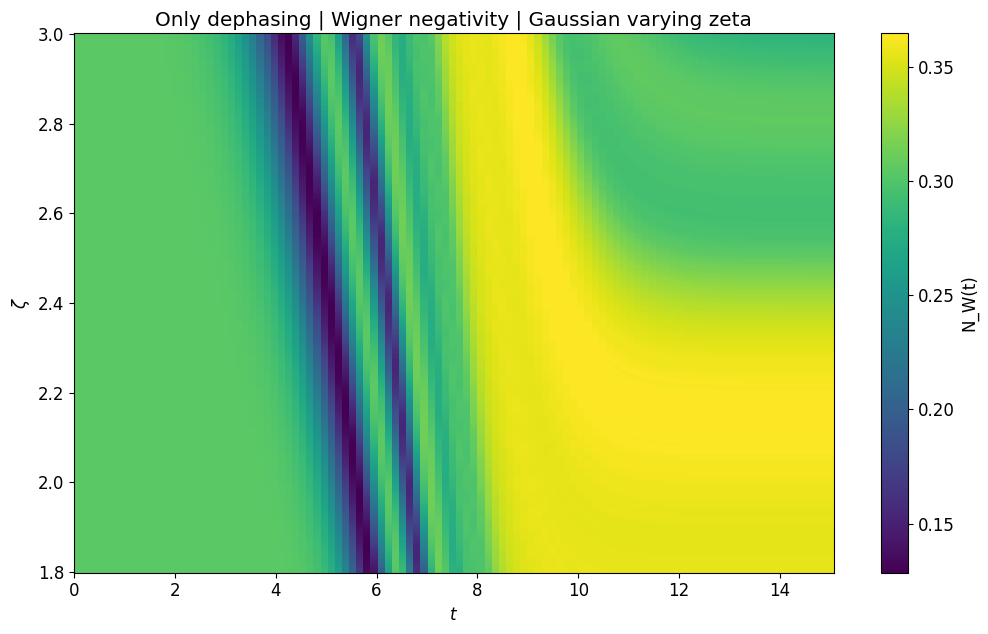

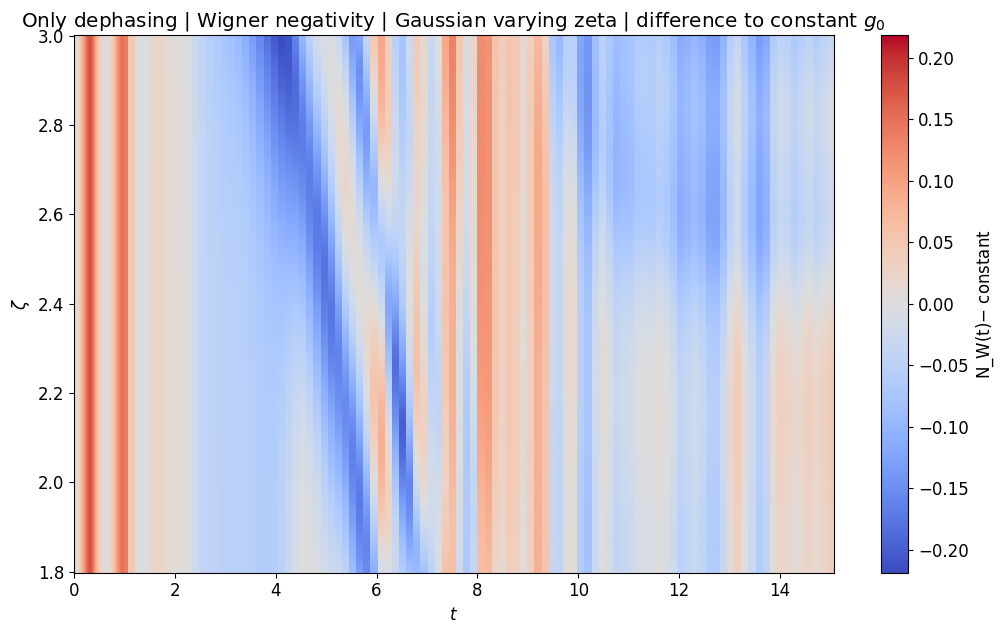

{'case_id': 'only_dephasing_wigner_gauss_zeta',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_wigner_gauss_zeta',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000000e-0

In [6]:
plot_surface_case(
    "only_dephasing_wigner_gauss_zeta",
    title="Only dephasing | Wigner negativity | Gaussian varying zeta",
)

## Gaussian varying $T$

only_dephasing_wigner_gauss_T
  shape var_aberto = (100, 200)
  t: 0.0 → 15.0 | n = 200
  parameter: 4.5 → 10.5 | n = 100


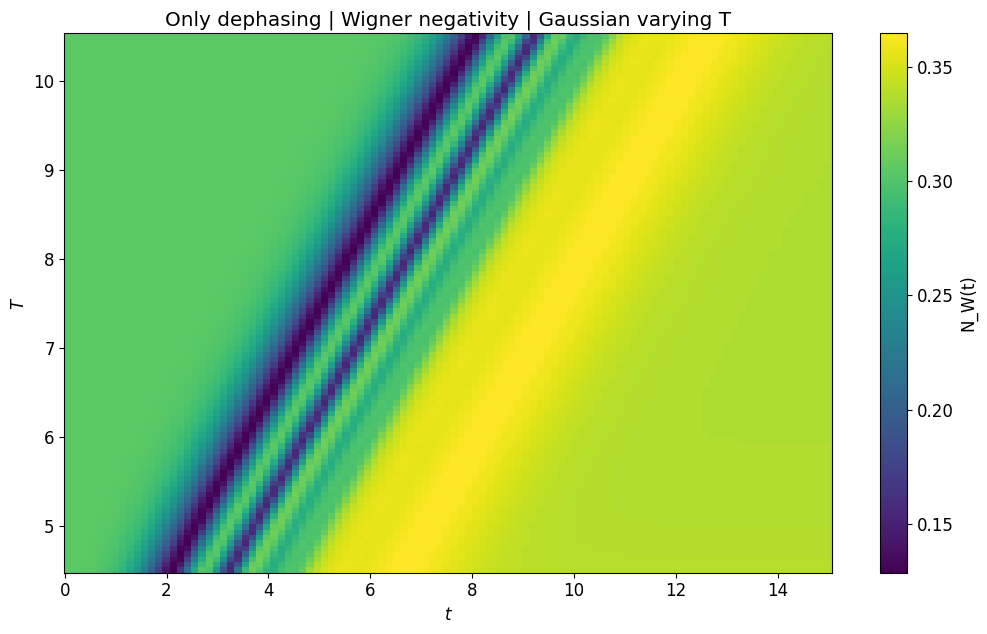

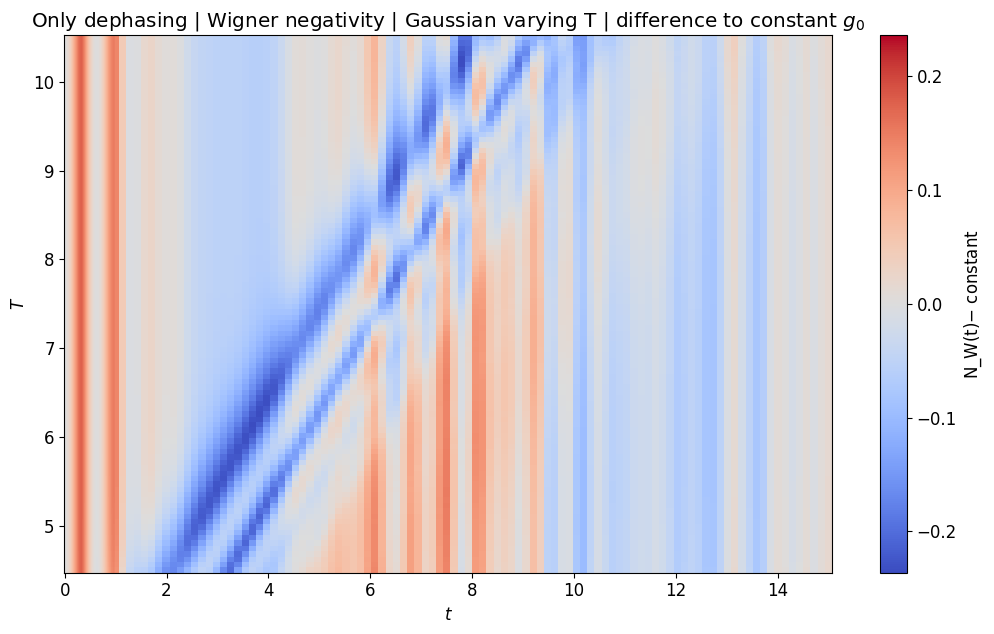

{'case_id': 'only_dephasing_wigner_gauss_T',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_wigner_gauss_T',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000000e-01, 4.7

In [7]:
plot_surface_case(
    "only_dephasing_wigner_gauss_T",
    title="Only dephasing | Wigner negativity | Gaussian varying T",
)

## Cosine varying $\omega$

only_dephasing_wigner_cos_omega
  shape var_aberto = (100, 200)
  t: 0.0 → 15.0 | n = 200
  parameter: 0.0 → 2.0943951023931953 | n = 100


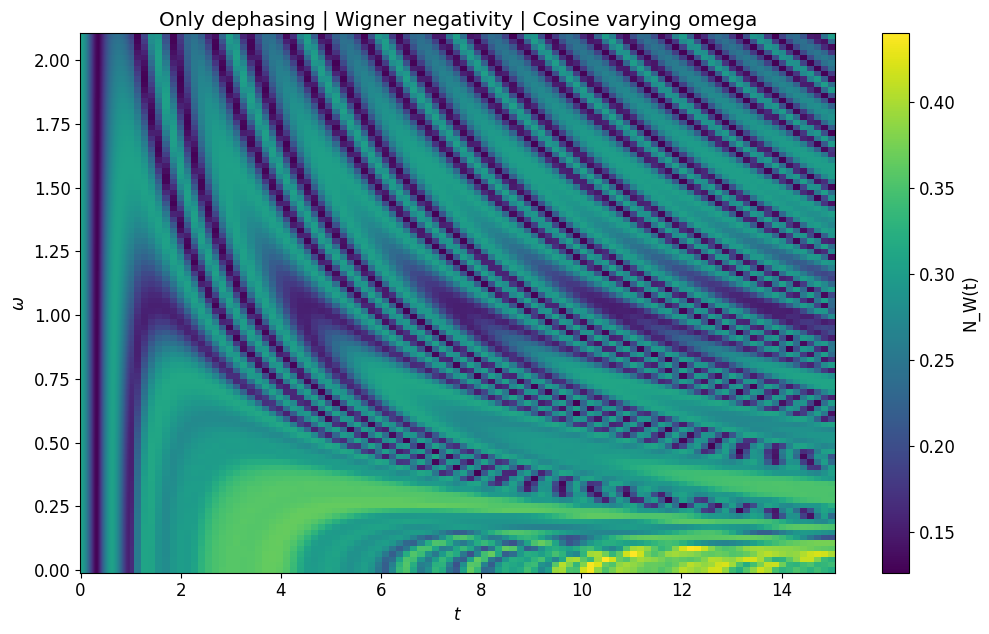

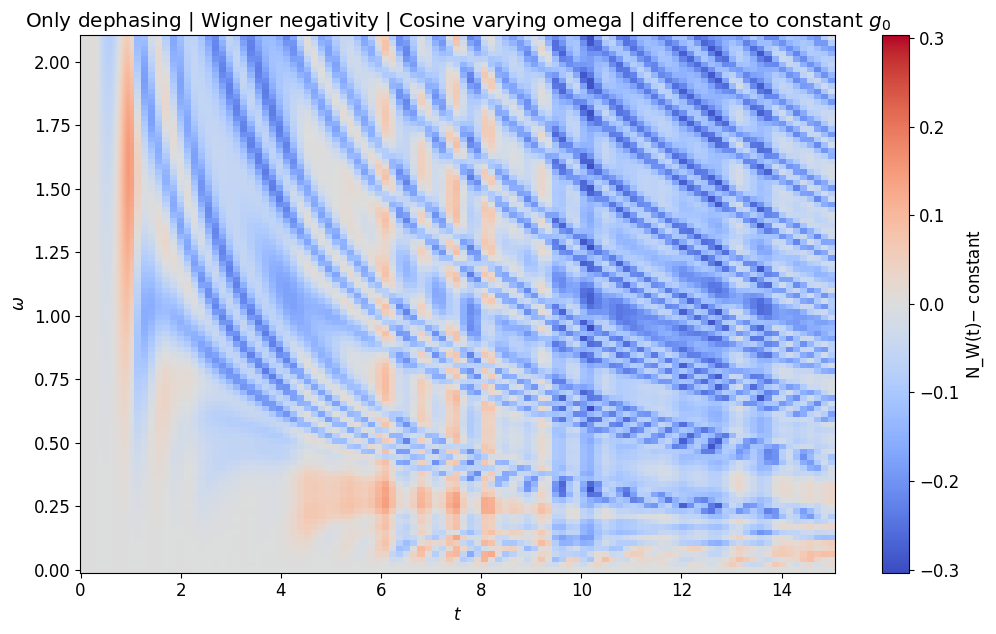

{'case_id': 'only_dephasing_wigner_cos_omega',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_wigner_cos_omega',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000000e-01,

In [8]:
plot_surface_case(
    "only_dephasing_wigner_cos_omega",
    title="Only dephasing | Wigner negativity | Cosine varying omega",
)

# Only dephasing — Coherence

## Gaussian varying $\zeta$

only_dephasing_coherence_gauss_zeta
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 6.0 → 10.0 | n = 100


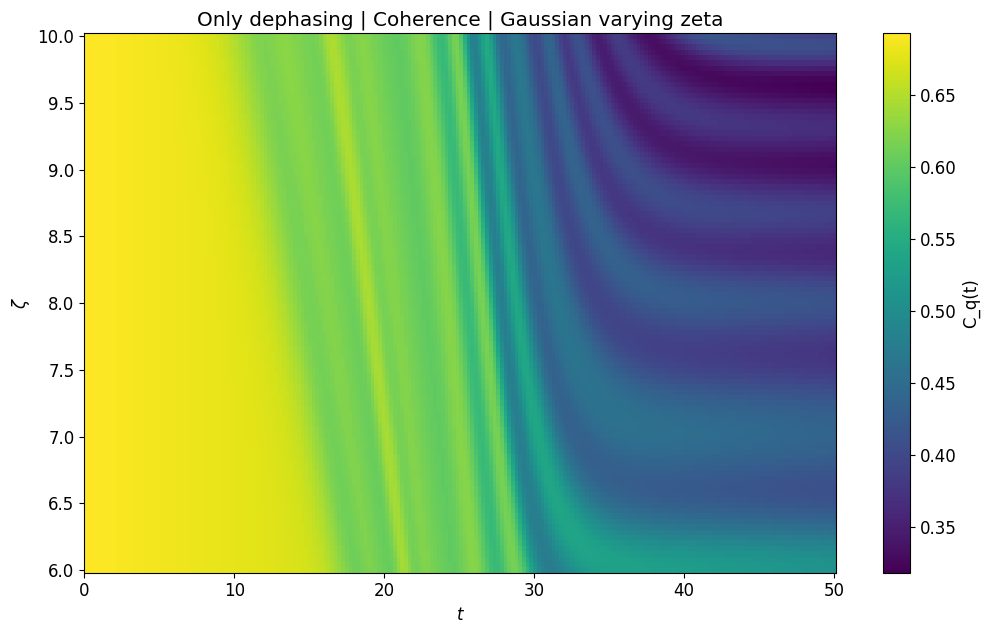

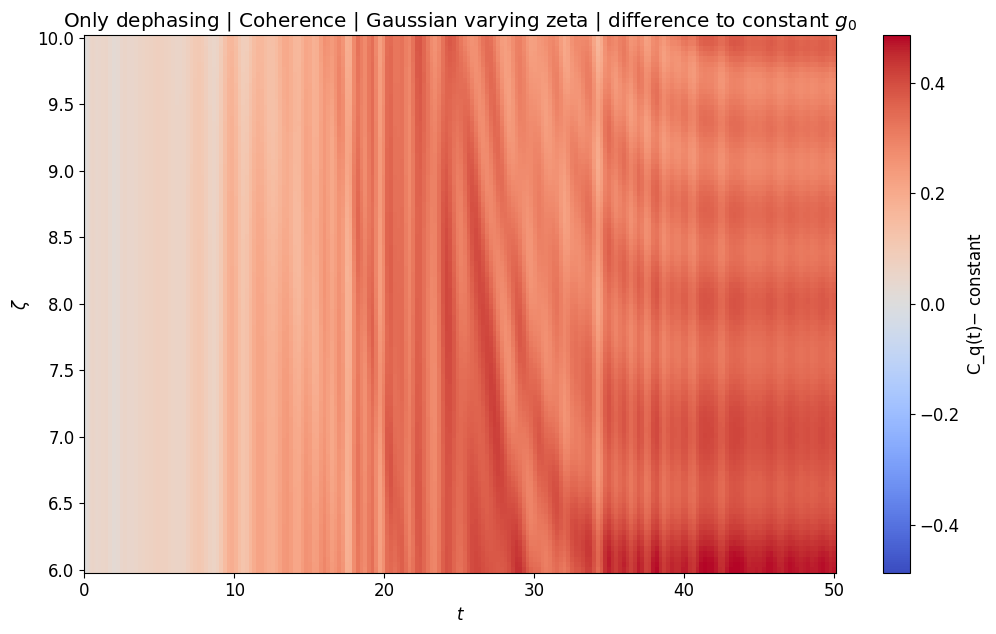

{'case_id': 'only_dephasing_coherence_gauss_zeta',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_coherence_gauss_zeta',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000

In [9]:
plot_surface_case(
    "only_dephasing_coherence_gauss_zeta",
    title="Only dephasing | Coherence | Gaussian varying zeta",
)

## Gaussian varying $T$

only_dephasing_coherence_gauss_T
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 15.0 → 35.0 | n = 100


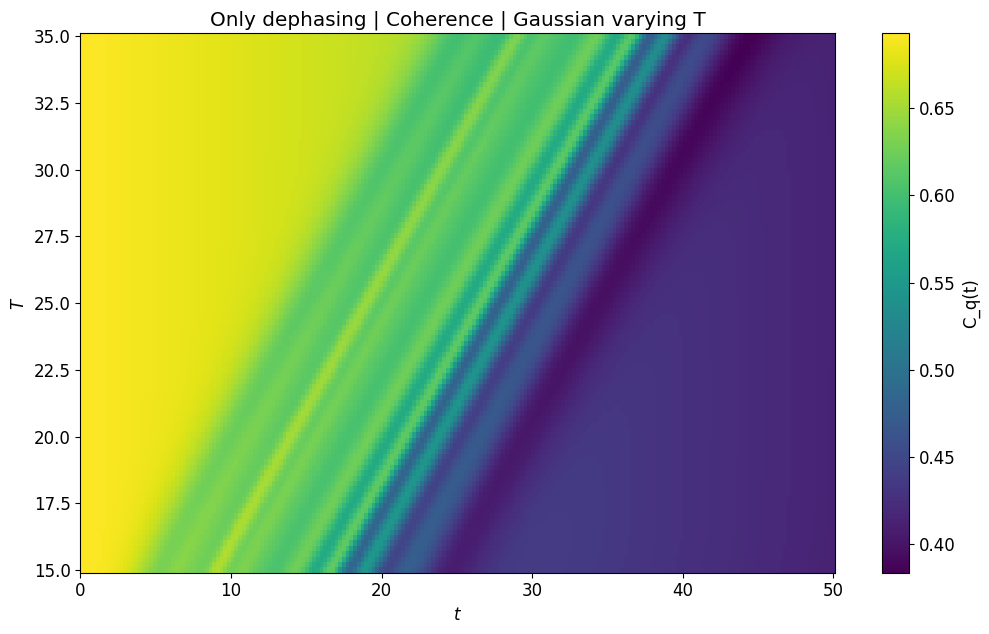

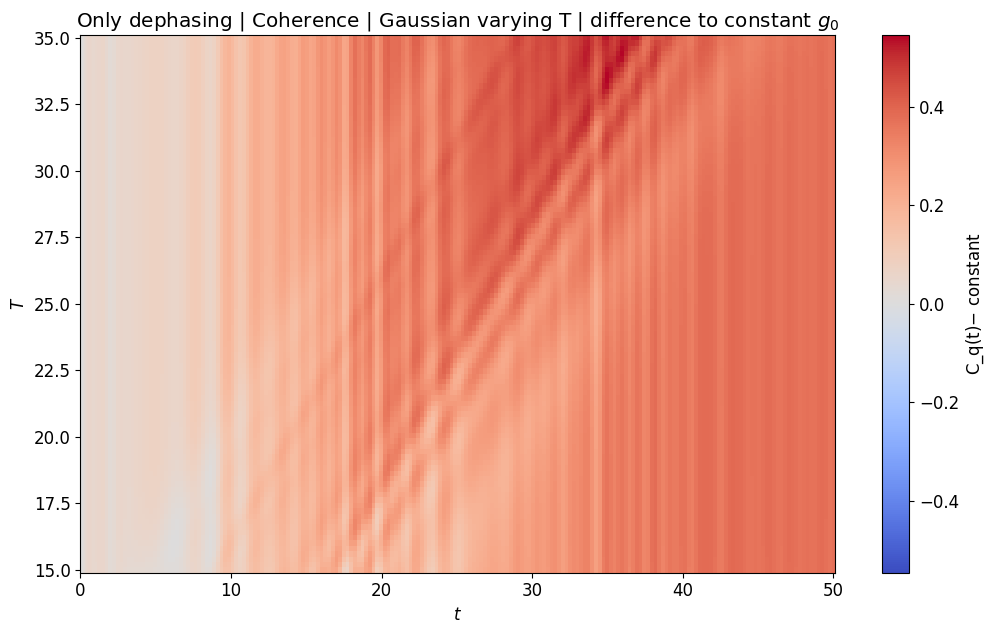

{'case_id': 'only_dephasing_coherence_gauss_T',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_coherence_gauss_T',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000000e-0

In [10]:
plot_surface_case(
    "only_dephasing_coherence_gauss_T",
    title="Only dephasing | Coherence | Gaussian varying T",
)

## Cosine varying $\omega$

only_dephasing_coherence_cos_omega
  shape var_aberto = (200, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 0.0 → 0.6283185307179586 | n = 200


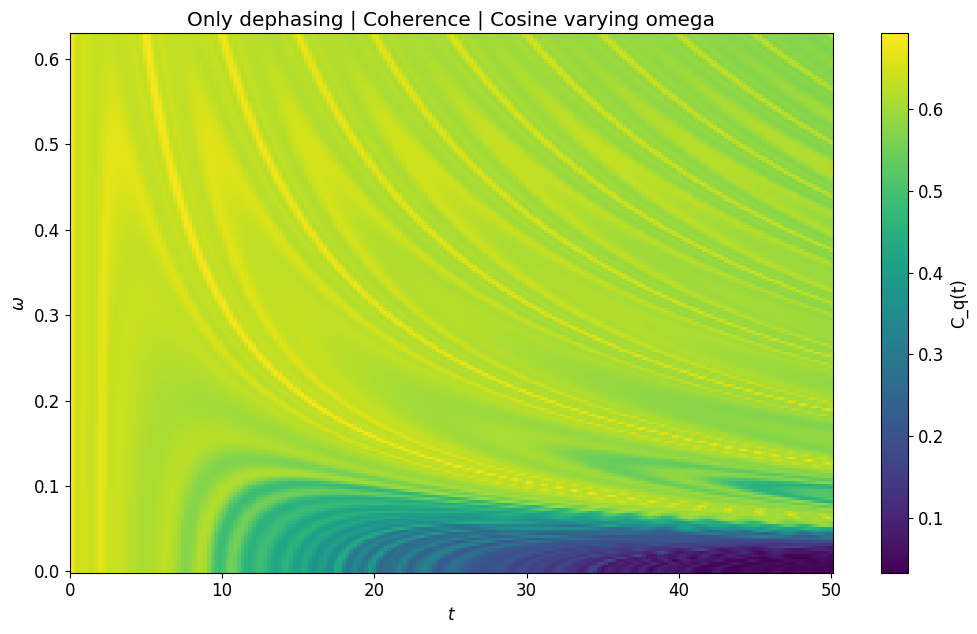

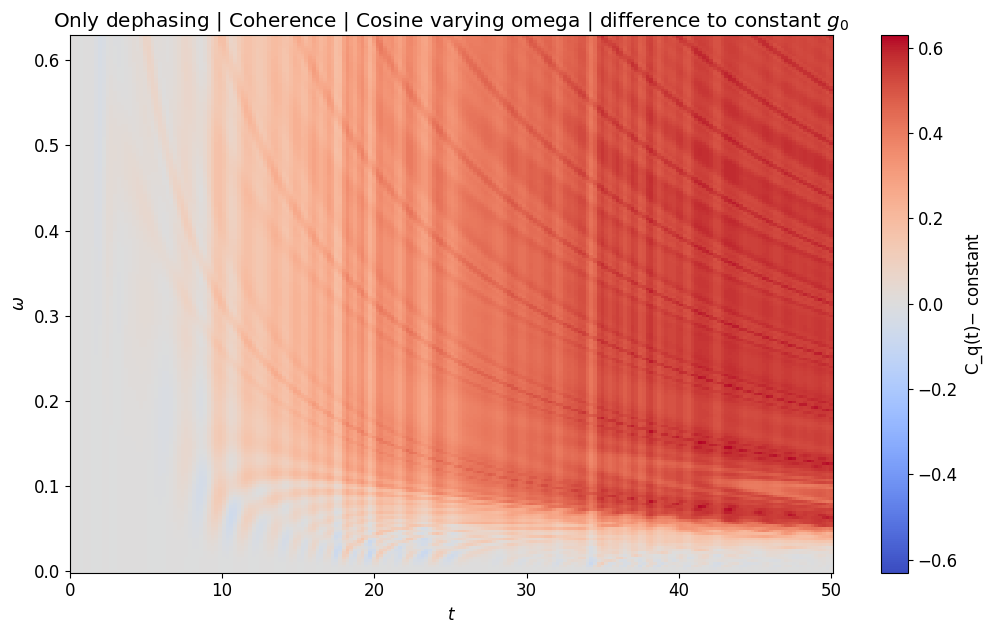

{'case_id': 'only_dephasing_coherence_cos_omega',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_coherence_cos_omega',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.6000000

In [11]:
plot_surface_case(
    "only_dephasing_coherence_cos_omega",
    title="Only dephasing | Coherence | Cosine varying omega",
)

# Only dephasing — Magic

## Gaussian varying $\zeta$

only_dephasing_magic_gauss_zeta
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 6.0 → 10.0 | n = 100


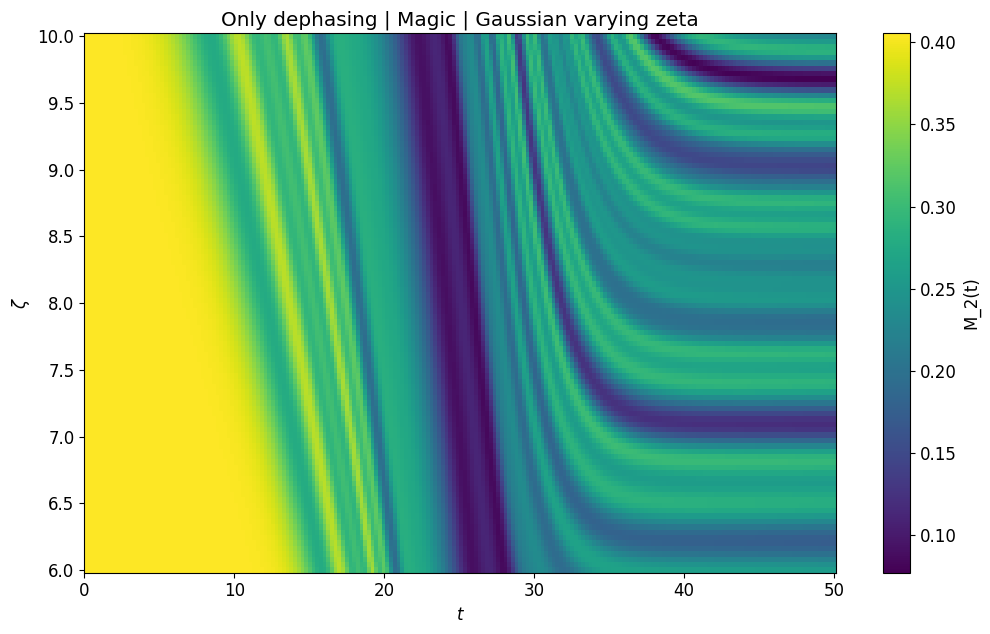

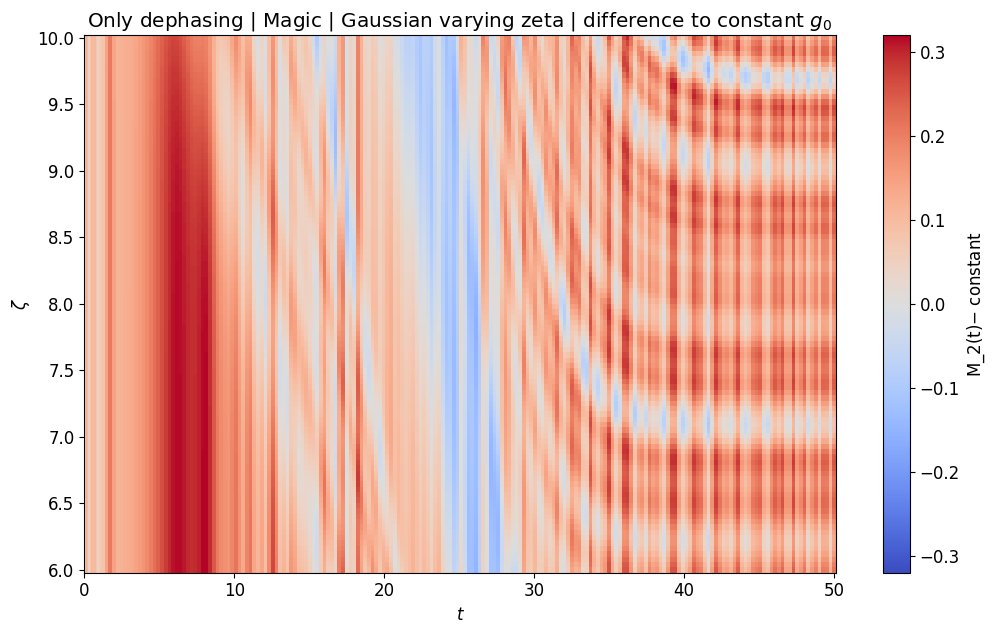

{'case_id': 'only_dephasing_magic_gauss_zeta',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_magic_gauss_zeta',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000000e-01,

In [12]:
plot_surface_case(
    "only_dephasing_magic_gauss_zeta",
    title="Only dephasing | Magic | Gaussian varying zeta",
)

## Gaussian varying $T$

only_dephasing_magic_gauss_T
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 15.0 → 35.0 | n = 100


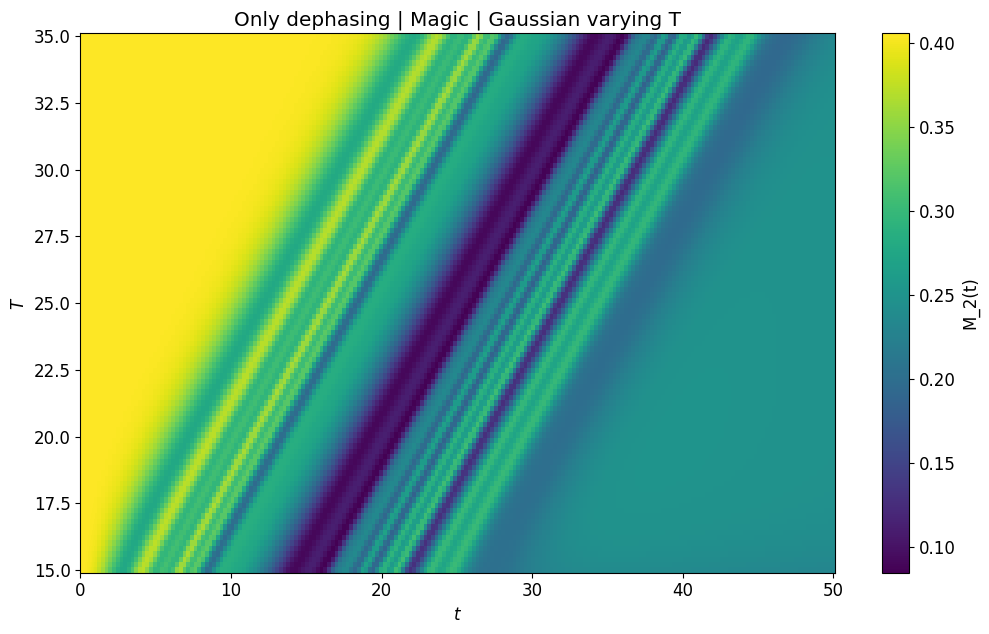

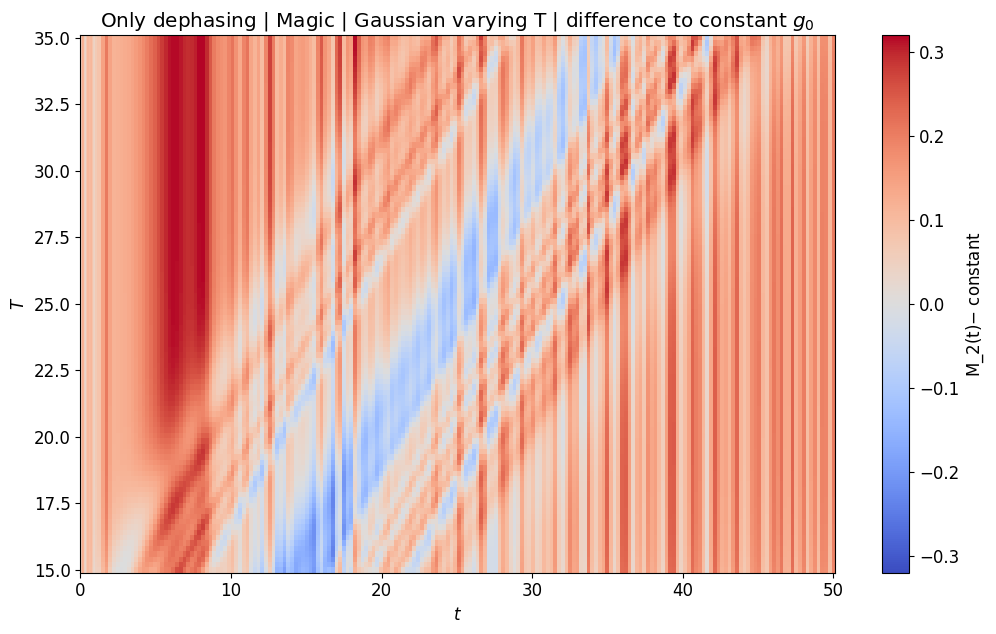

{'case_id': 'only_dephasing_magic_gauss_T',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_magic_gauss_T',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000000e-01, 4.700

In [13]:
plot_surface_case(
    "only_dephasing_magic_gauss_T",
    title="Only dephasing | Magic | Gaussian varying T",
)

## Cosine varying $\omega$

only_dephasing_magic_cos_omega
  shape var_aberto = (200, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 0.0 → 0.6283185307179586 | n = 200


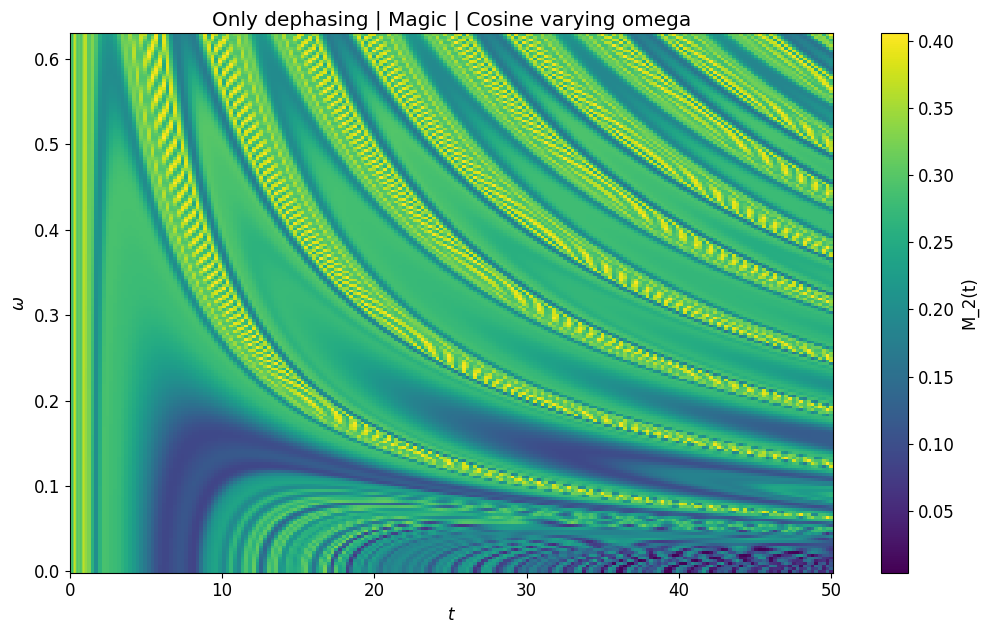

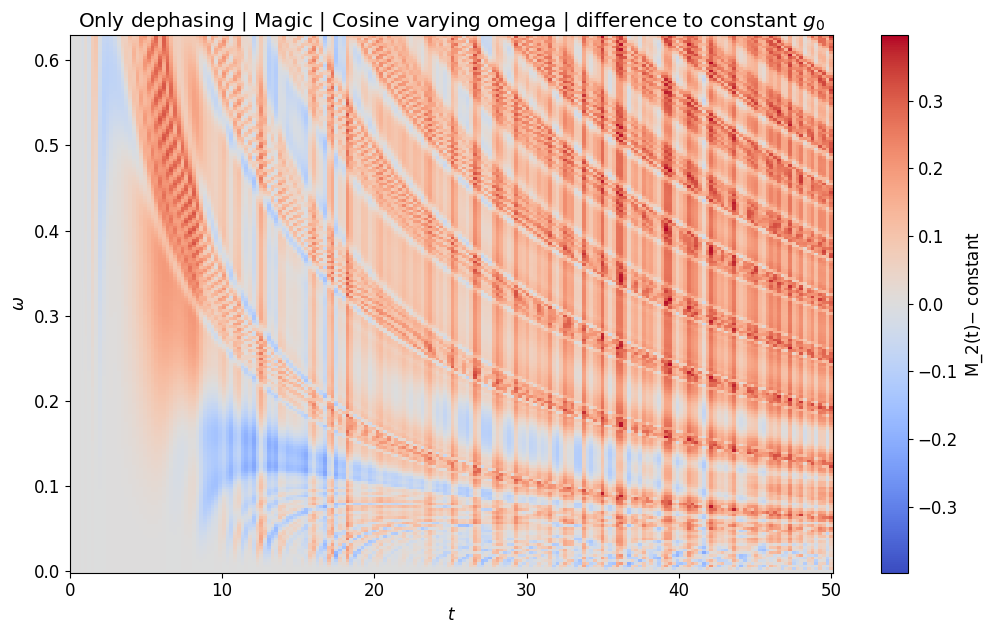

{'case_id': 'only_dephasing_magic_cos_omega',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_magic_cos_omega',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000000e-01, 4

In [14]:
plot_surface_case(
    "only_dephasing_magic_cos_omega",
    title="Only dephasing | Magic | Cosine varying omega",
)

# Only dephasing — Entanglement

## Gaussian varying $\zeta$

only_dephasing_entanglement_gauss_zeta
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 6.0 → 10.0 | n = 100


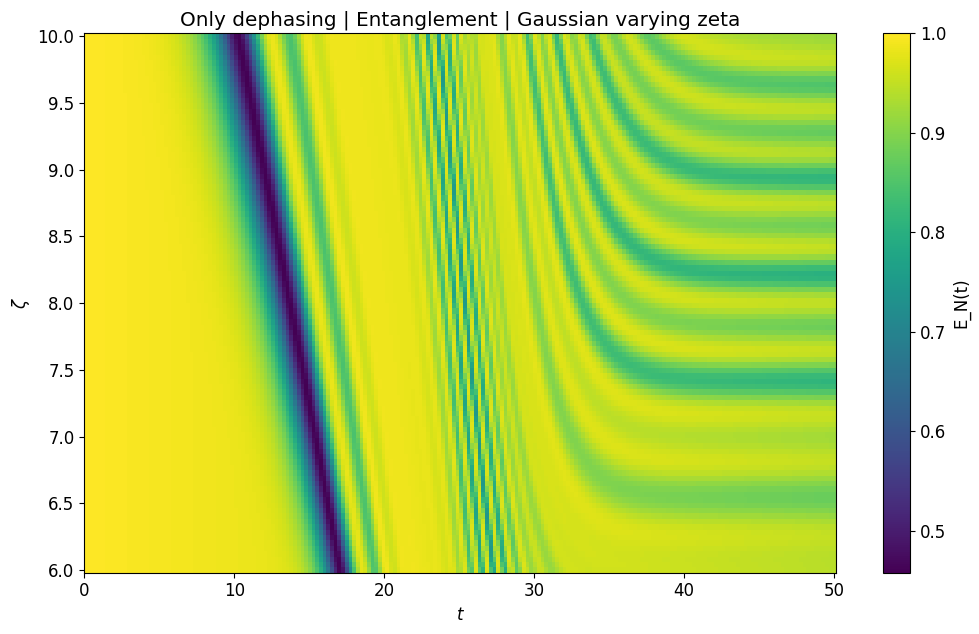

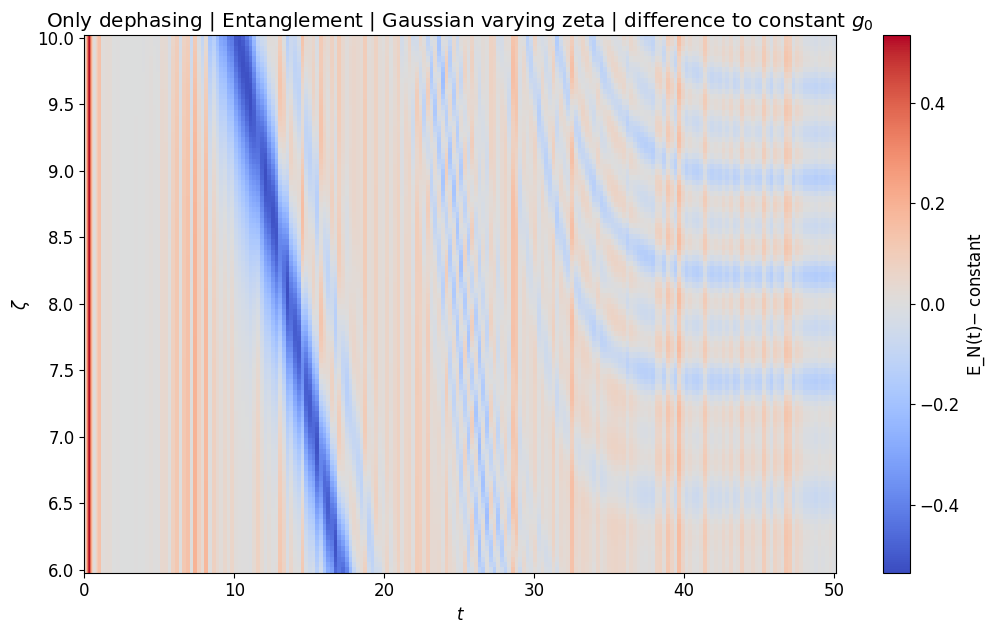

{'case_id': 'only_dephasing_entanglement_gauss_zeta',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_entanglement_gauss_zeta',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4

In [15]:
plot_surface_case(
    "only_dephasing_entanglement_gauss_zeta",
    title="Only dephasing | Entanglement | Gaussian varying zeta",
)

## Gaussian varying $T$

only_dephasing_entanglement_gauss_T
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 15.0 → 35.0 | n = 100


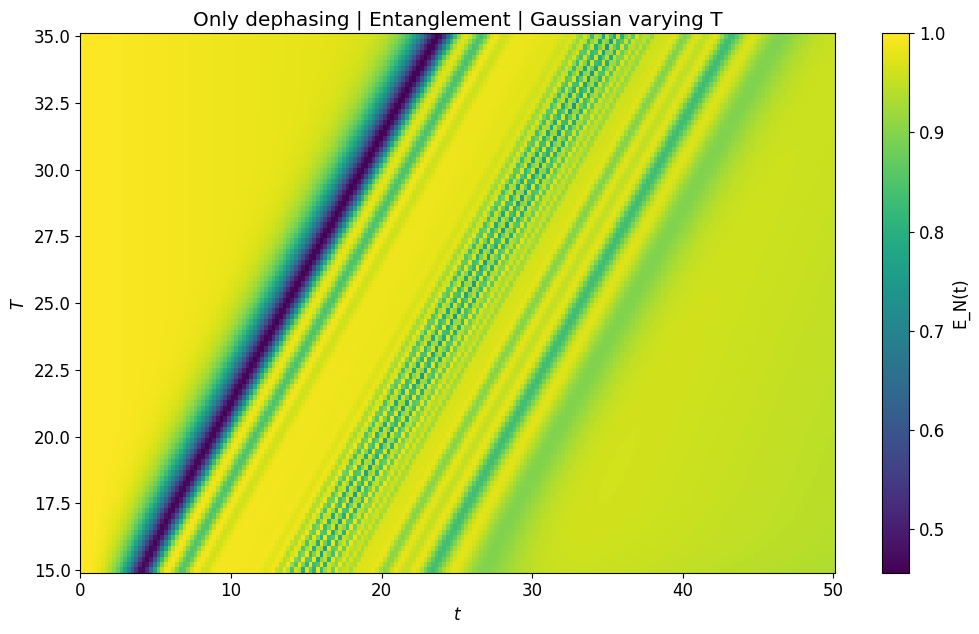

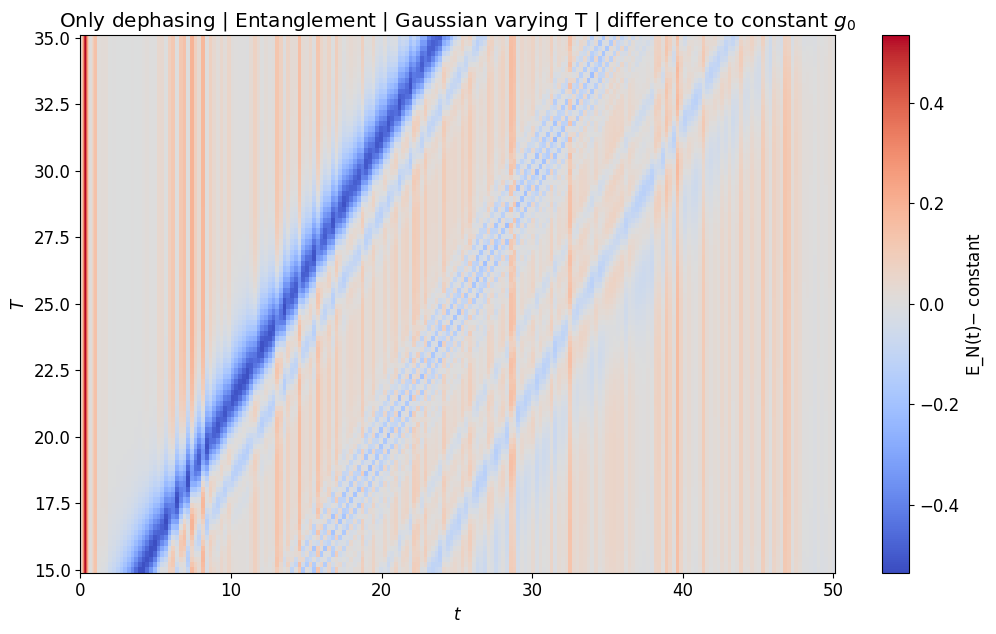

{'case_id': 'only_dephasing_entanglement_gauss_T',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_entanglement_gauss_T',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000

In [16]:
plot_surface_case(
    "only_dephasing_entanglement_gauss_T",
    title="Only dephasing | Entanglement | Gaussian varying T",
)

## Cosine varying $\omega$

only_dephasing_entanglement_cos_omega
  shape var_aberto = (200, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 0.0 → 0.6283185307179586 | n = 200


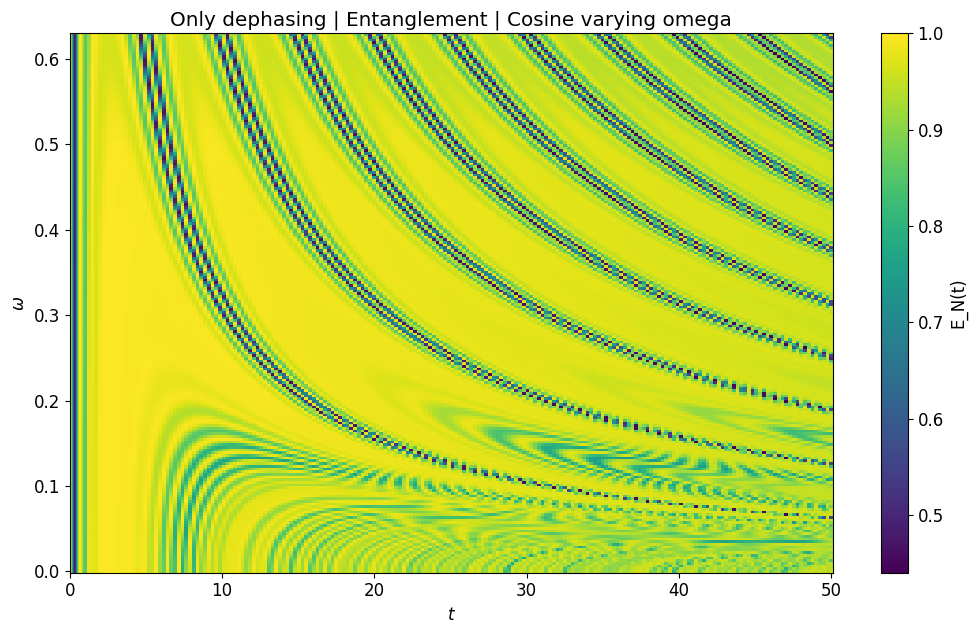

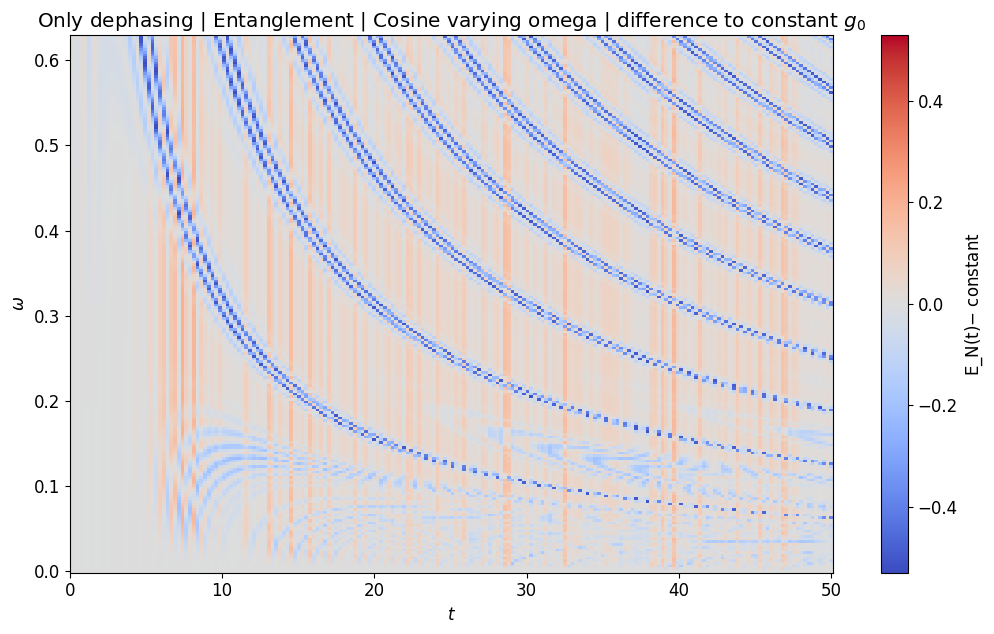

{'case_id': 'only_dephasing_entanglement_cos_omega',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_dephasing_entanglement_cos_omega',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.6

In [17]:
plot_surface_case(
    "only_dephasing_entanglement_cos_omega",
    title="Only dephasing | Entanglement | Cosine varying omega",
)

# Only cavity damping — Wigner negativity

## Gaussian varying $\zeta$

only_cavity_damping_wigner_gauss_zeta
  shape var_aberto = (250, 200)
  t: 0.0 → 15.0 | n = 200
  parameter: 1.8 → 3.0 | n = 250


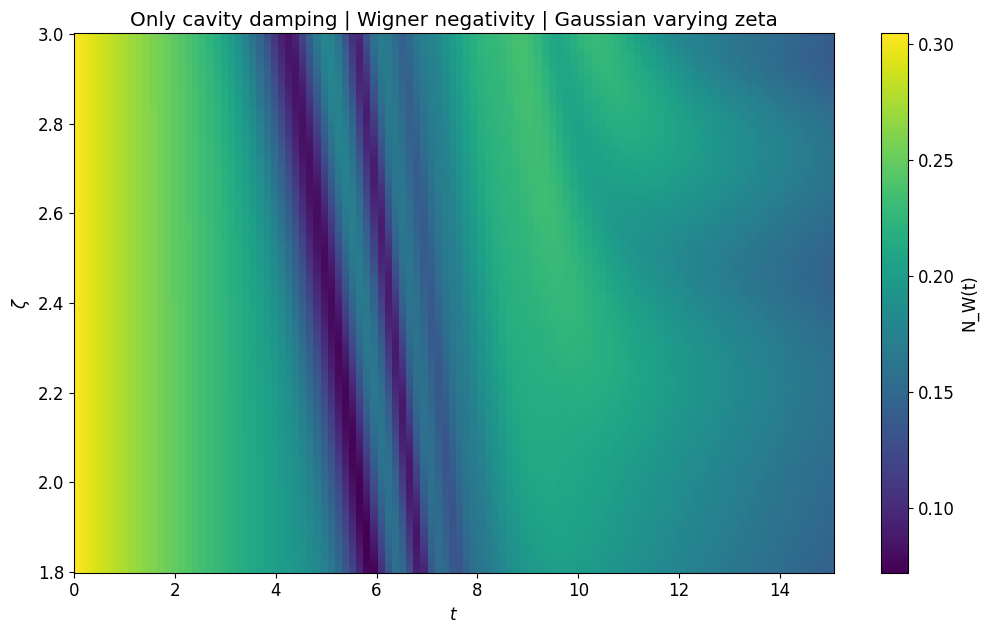

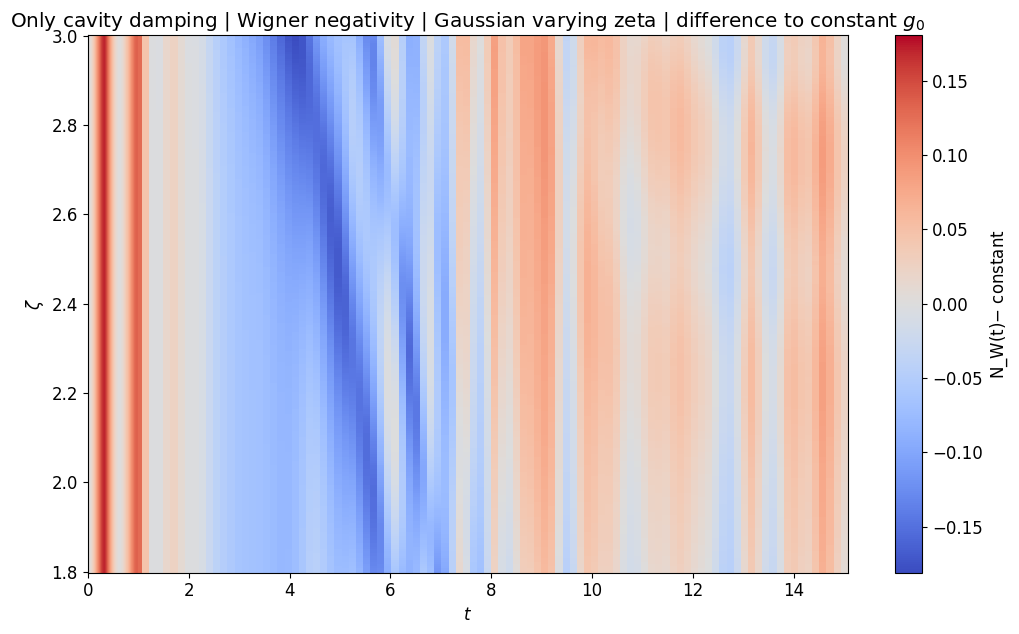

{'case_id': 'only_cavity_damping_wigner_gauss_zeta',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_wigner_gauss_zeta',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.6

In [18]:
plot_surface_case(
    "only_cavity_damping_wigner_gauss_zeta",
    title="Only cavity damping | Wigner negativity | Gaussian varying zeta",
)

## Gaussian varying $T$

only_cavity_damping_wigner_gauss_T
  shape var_aberto = (100, 200)
  t: 0.0 → 15.0 | n = 200
  parameter: 4.5 → 10.5 | n = 100


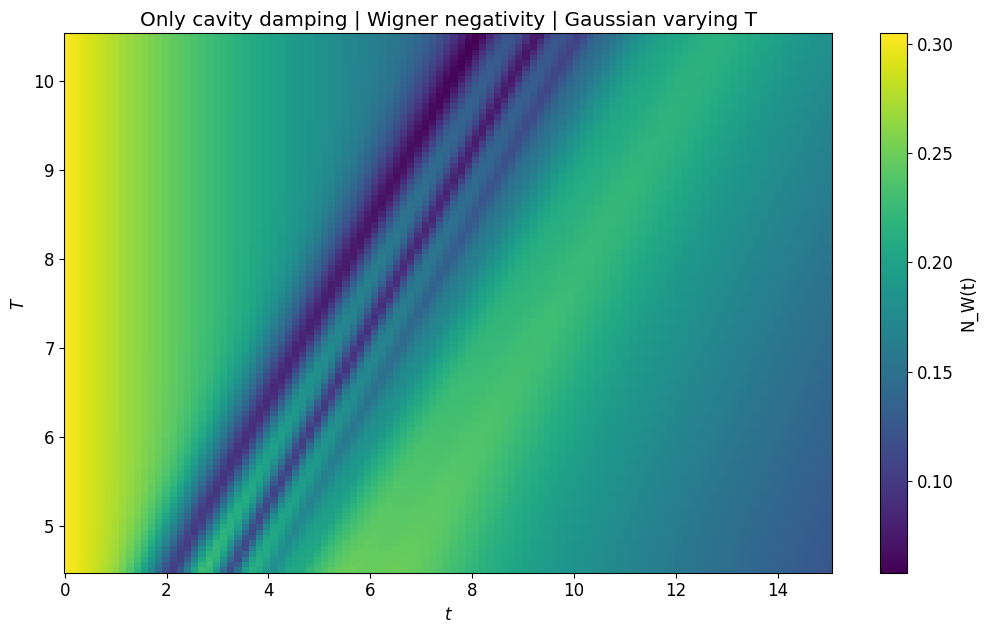

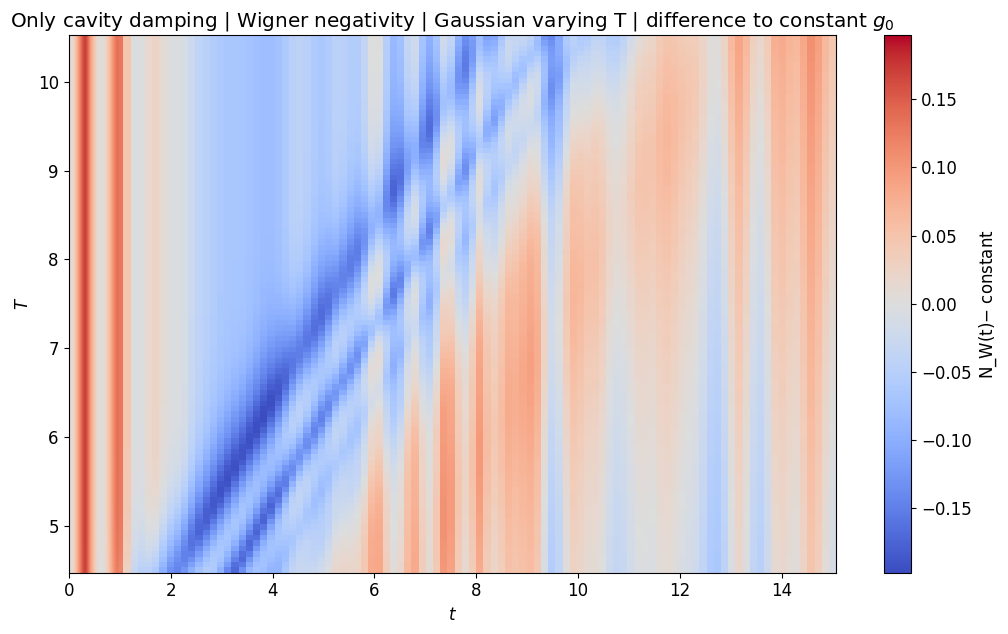

{'case_id': 'only_cavity_damping_wigner_gauss_T',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_wigner_gauss_T',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.6000000

In [19]:
plot_surface_case(
    "only_cavity_damping_wigner_gauss_T",
    title="Only cavity damping | Wigner negativity | Gaussian varying T",
)

## Cosine varying $\omega$

only_cavity_damping_wigner_cos_omega
  shape var_aberto = (100, 200)
  t: 0.0 → 15.0 | n = 200
  parameter: 0.0 → 2.0943951023931953 | n = 100


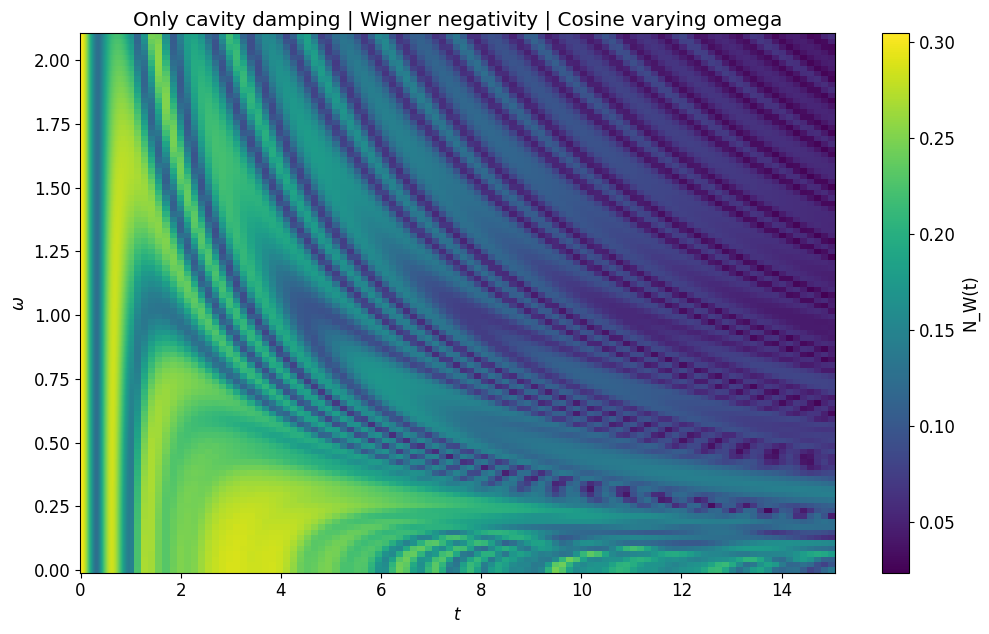

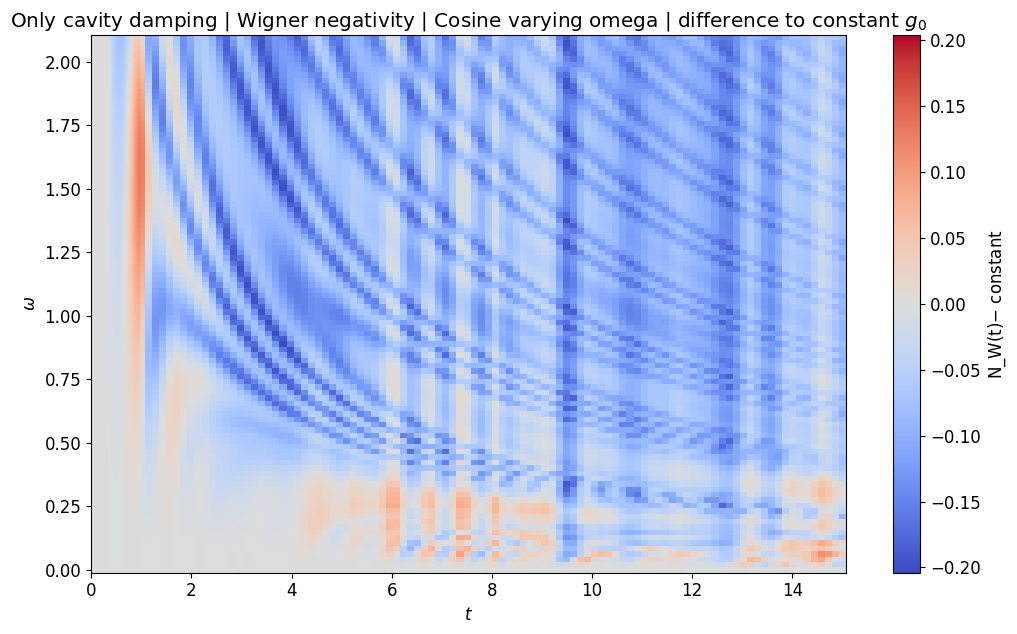

{'case_id': 'only_cavity_damping_wigner_cos_omega',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_wigner_cos_omega',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.600

In [20]:
plot_surface_case(
    "only_cavity_damping_wigner_cos_omega",
    title="Only cavity damping | Wigner negativity | Cosine varying omega",
)

# Only cavity damping — Coherence

## Gaussian varying $\zeta$

only_cavity_damping_coherence_gauss_zeta
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 6.0 → 10.0 | n = 100


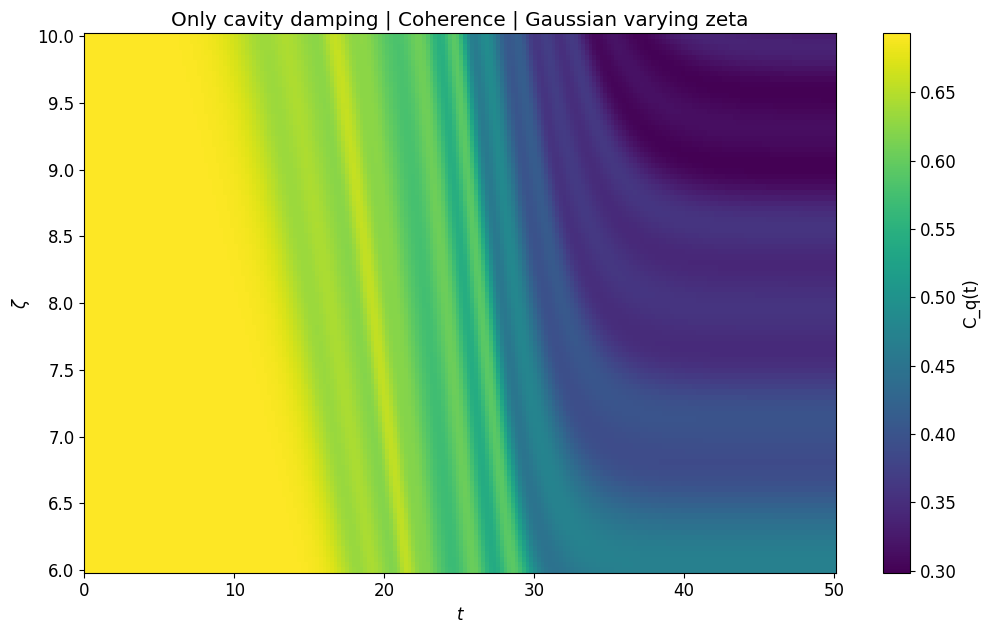

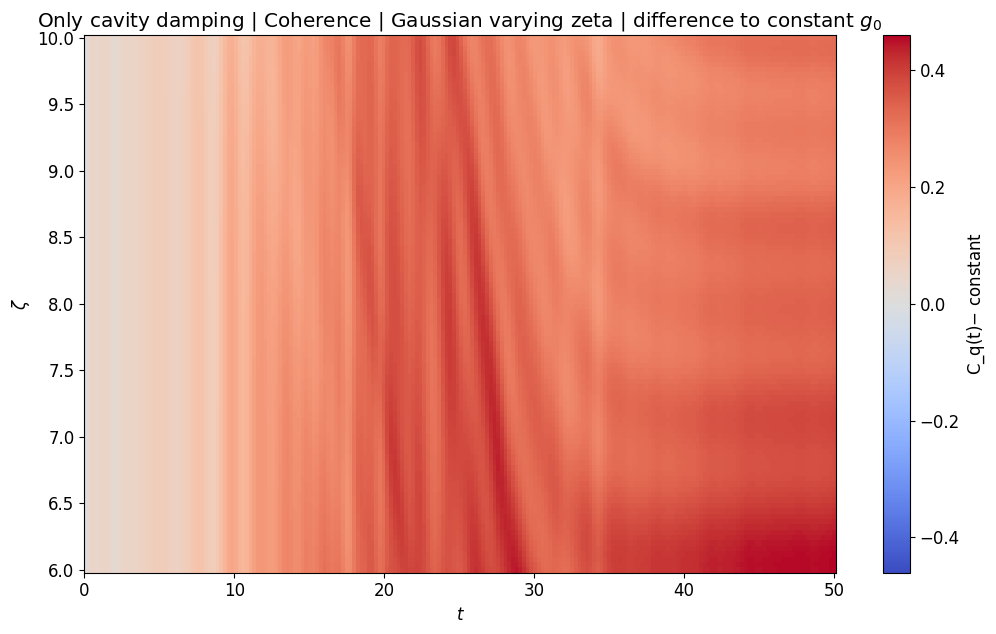

{'case_id': 'only_cavity_damping_coherence_gauss_zeta',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_coherence_gauss_zeta',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-0

In [21]:
plot_surface_case(
    "only_cavity_damping_coherence_gauss_zeta",
    title="Only cavity damping | Coherence | Gaussian varying zeta",
)

## Gaussian varying $T$

only_cavity_damping_coherence_gauss_T
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 15.0 → 35.0 | n = 100


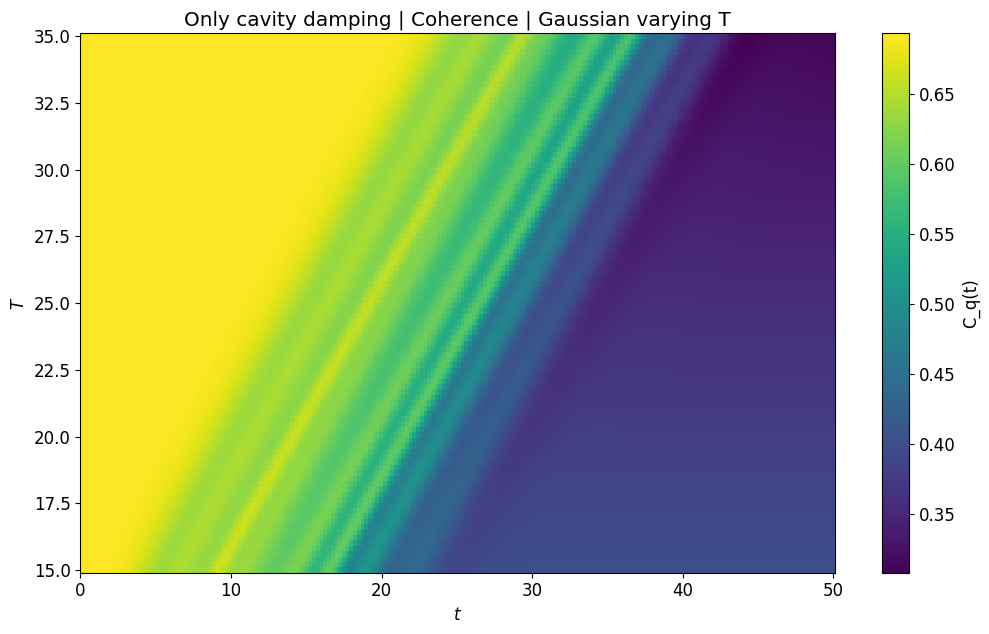

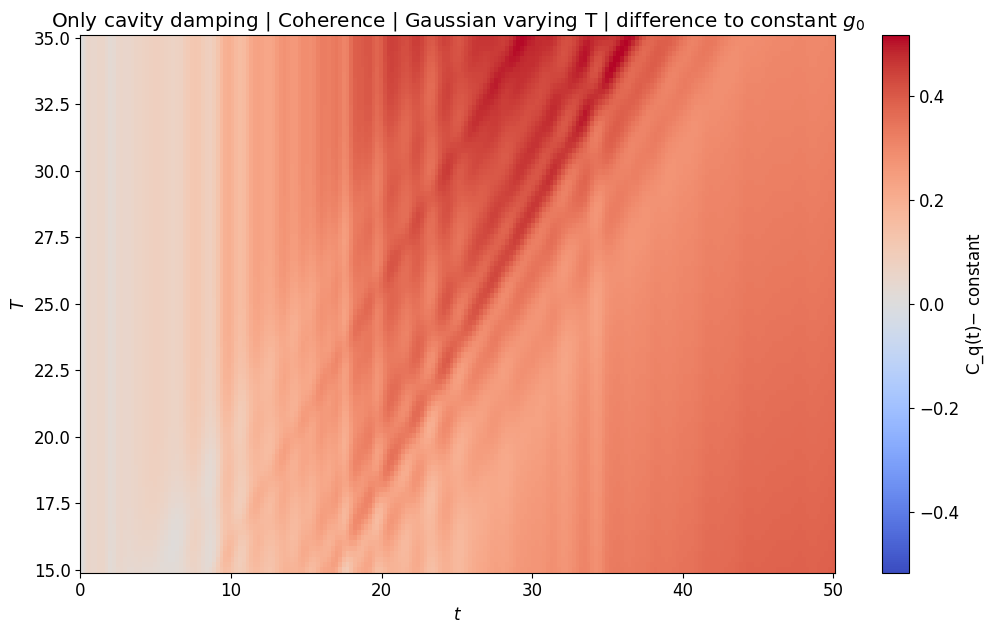

{'case_id': 'only_cavity_damping_coherence_gauss_T',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_coherence_gauss_T',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.6

In [22]:
plot_surface_case(
    "only_cavity_damping_coherence_gauss_T",
    title="Only cavity damping | Coherence | Gaussian varying T",
)

## Cosine varying $\omega$

only_cavity_damping_coherence_cos_omega
  shape var_aberto = (200, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 0.0 → 0.6283185307179586 | n = 200


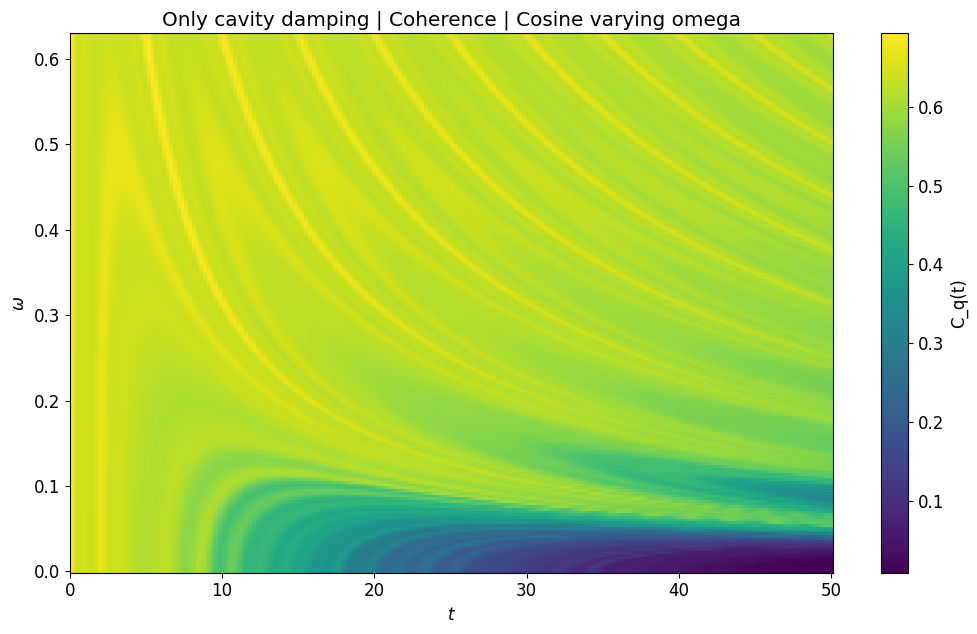

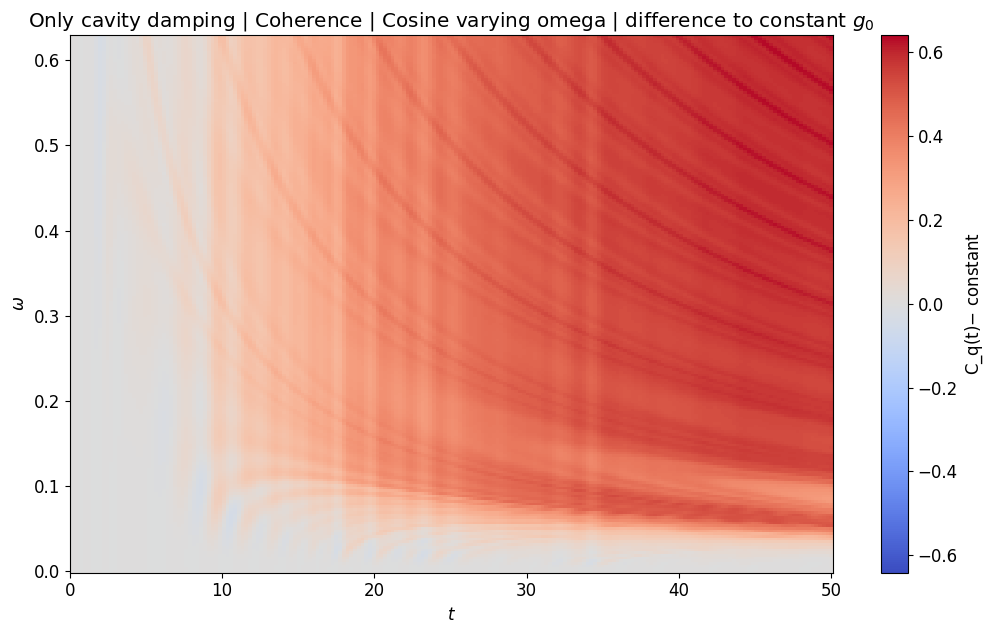

{'case_id': 'only_cavity_damping_coherence_cos_omega',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_coherence_cos_omega',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01,

In [23]:
plot_surface_case(
    "only_cavity_damping_coherence_cos_omega",
    title="Only cavity damping | Coherence | Cosine varying omega",
)

# Only cavity damping — Magic

## Gaussian varying $\zeta$

only_cavity_damping_magic_gauss_zeta
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 6.0 → 10.0 | n = 100


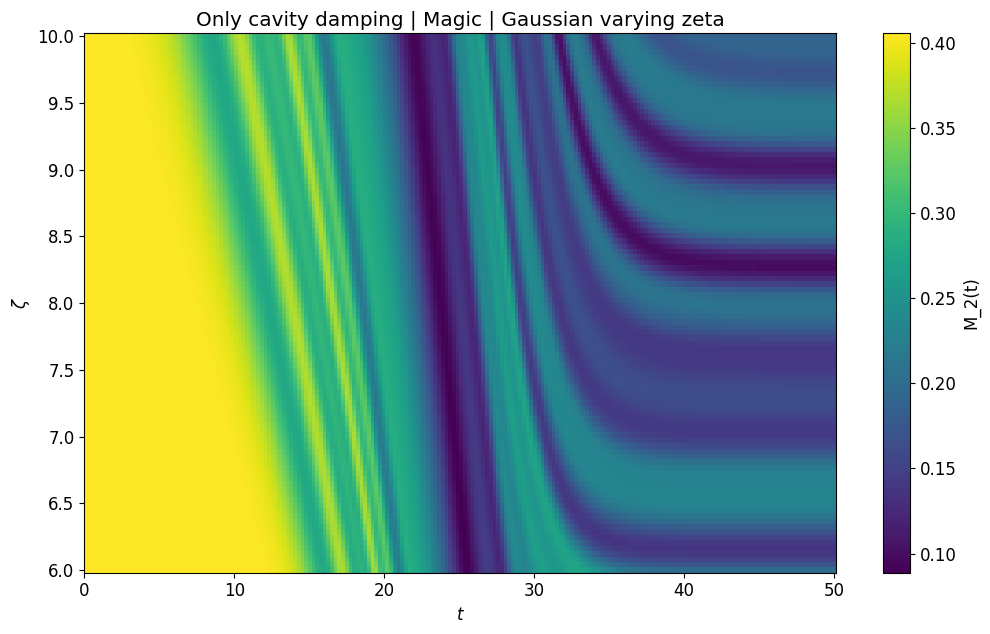

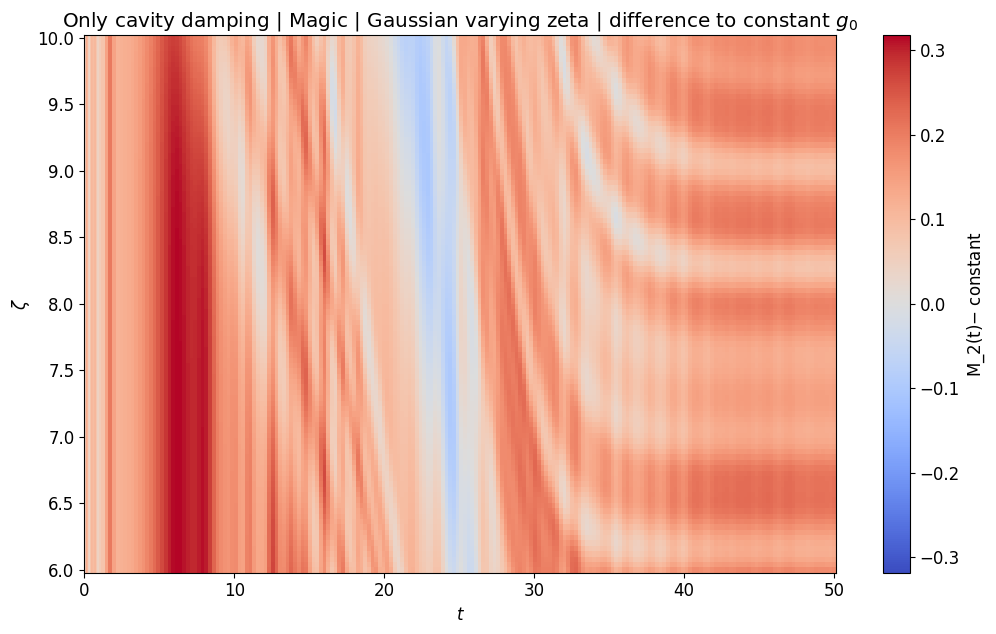

{'case_id': 'only_cavity_damping_magic_gauss_zeta',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_magic_gauss_zeta',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.600

In [24]:
plot_surface_case(
    "only_cavity_damping_magic_gauss_zeta",
    title="Only cavity damping | Magic | Gaussian varying zeta",
)

## Gaussian varying $T$

only_cavity_damping_magic_gauss_T
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 15.0 → 35.0 | n = 100


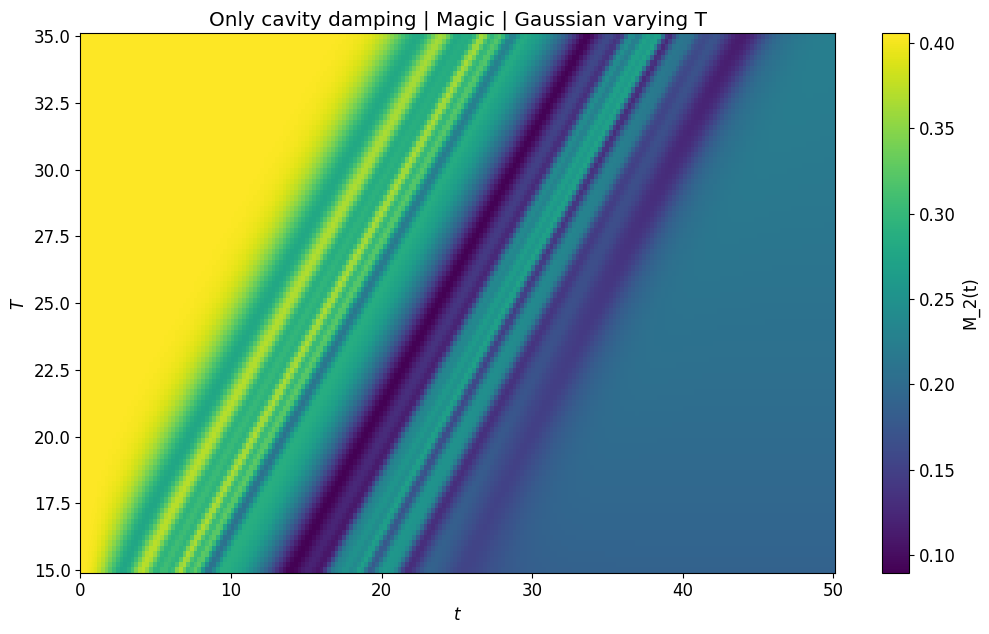

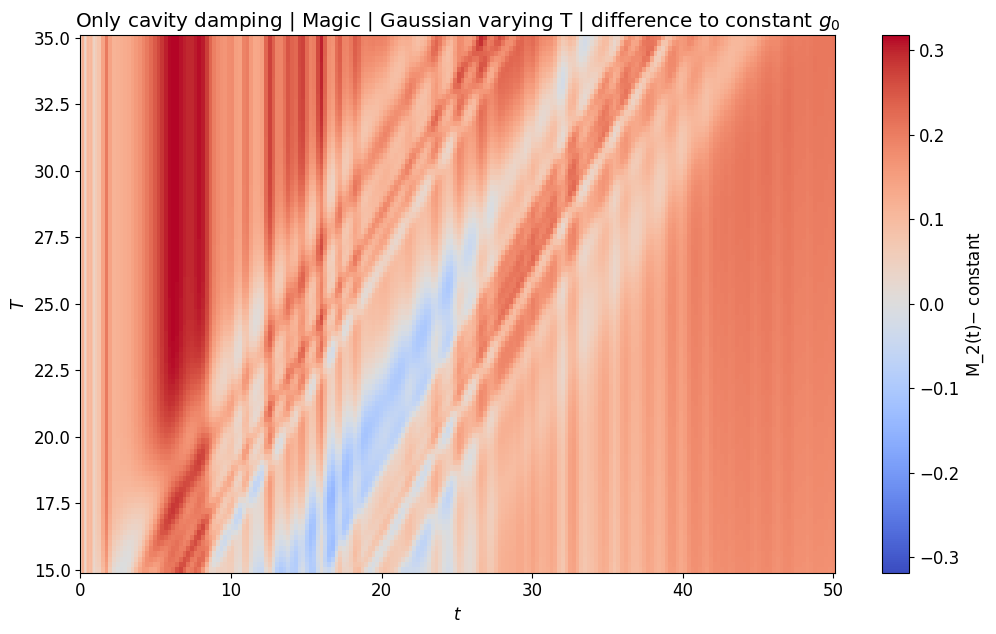

{'case_id': 'only_cavity_damping_magic_gauss_T',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_magic_gauss_T',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000000e

In [25]:
plot_surface_case(
    "only_cavity_damping_magic_gauss_T",
    title="Only cavity damping | Magic | Gaussian varying T",
)

## Cosine varying $\omega$

only_cavity_damping_magic_cos_omega
  shape var_aberto = (200, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 0.0 → 0.6283185307179586 | n = 200


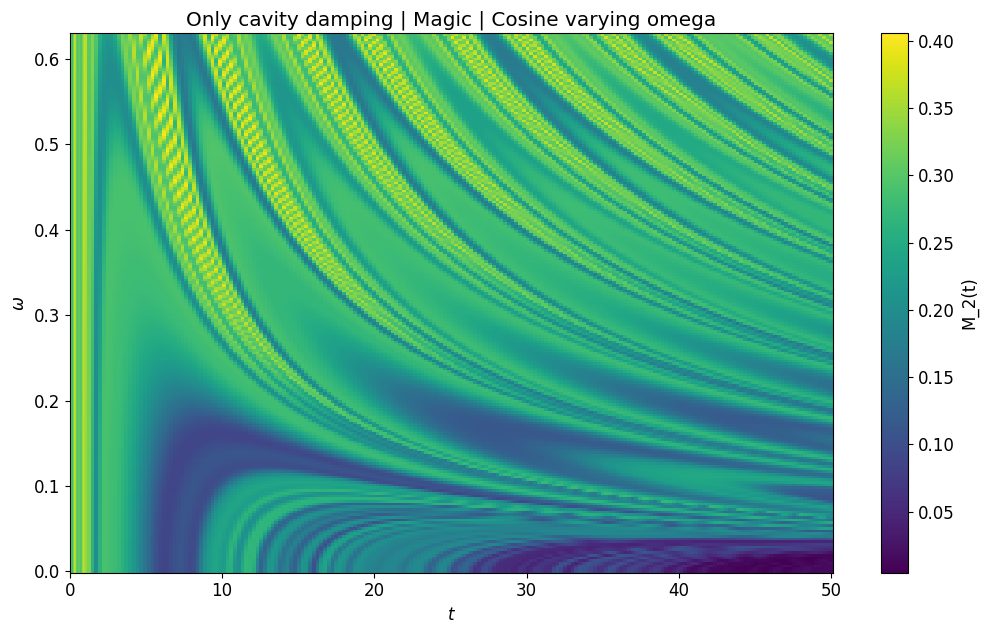

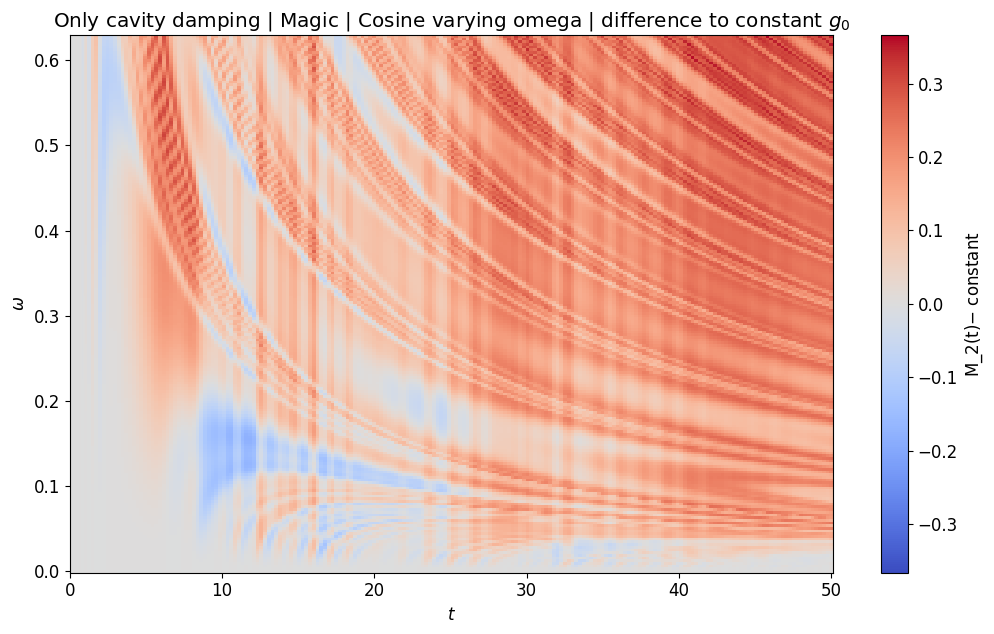

{'case_id': 'only_cavity_damping_magic_cos_omega',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_magic_cos_omega',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-01, 4.60000

In [26]:
plot_surface_case(
    "only_cavity_damping_magic_cos_omega",
    title="Only cavity damping | Magic | Cosine varying omega",
)

# Only cavity damping — Entanglement

## Gaussian varying $\zeta$

only_cavity_damping_entanglement_gauss_zeta
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 6.0 → 10.0 | n = 100


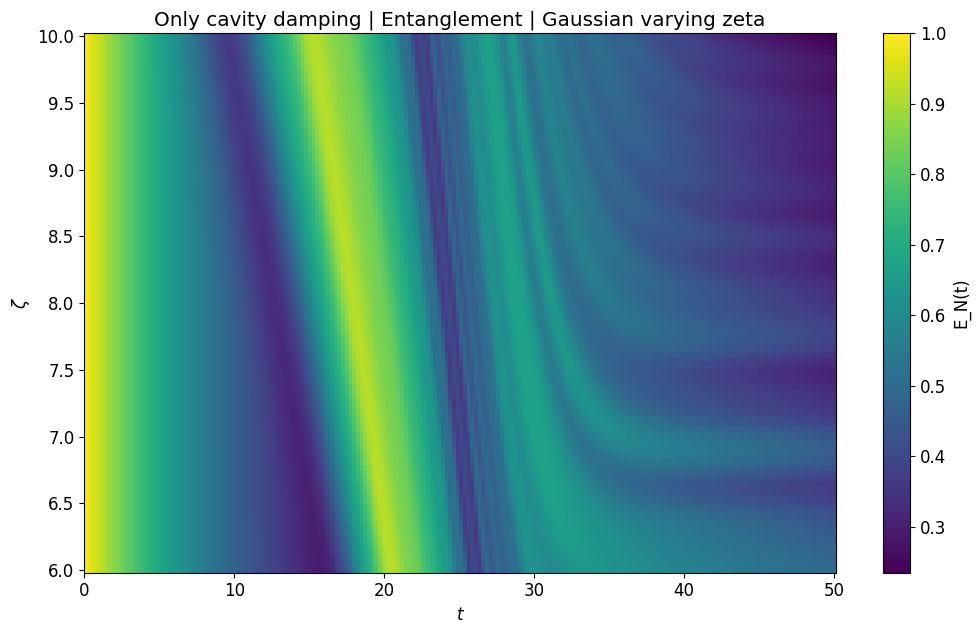

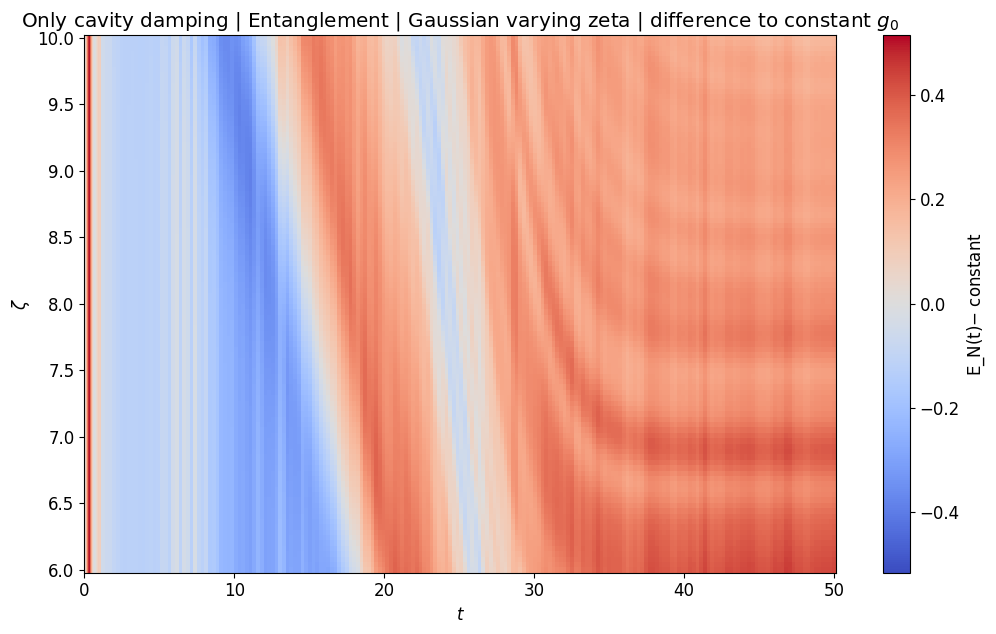

{'case_id': 'only_cavity_damping_entanglement_gauss_zeta',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_entanglement_gauss_zeta',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000

In [27]:
plot_surface_case(
    "only_cavity_damping_entanglement_gauss_zeta",
    title="Only cavity damping | Entanglement | Gaussian varying zeta",
)

## Gaussian varying $T$

only_cavity_damping_entanglement_gauss_T
  shape var_aberto = (100, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 15.0 → 35.0 | n = 100


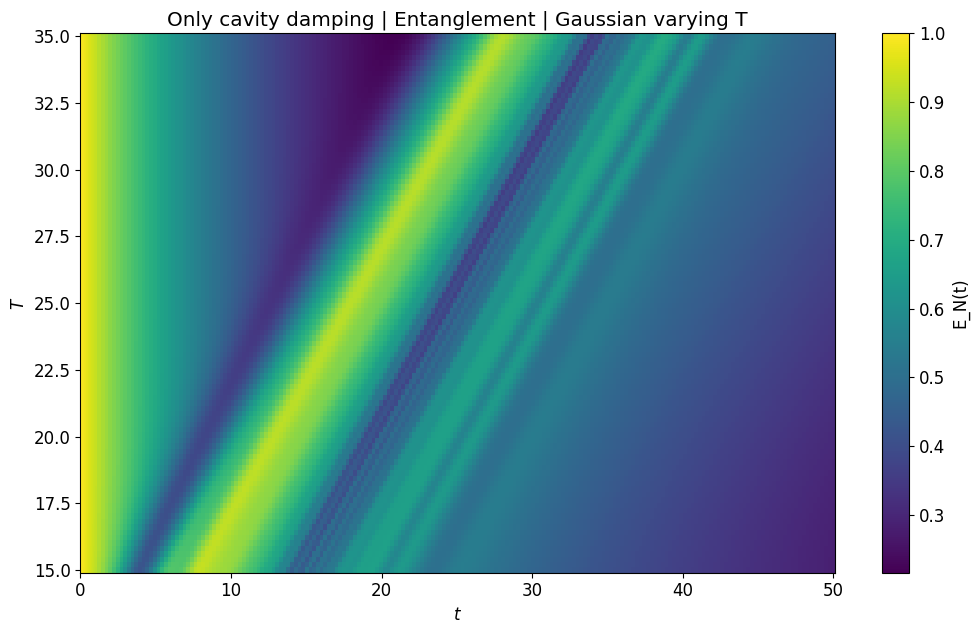

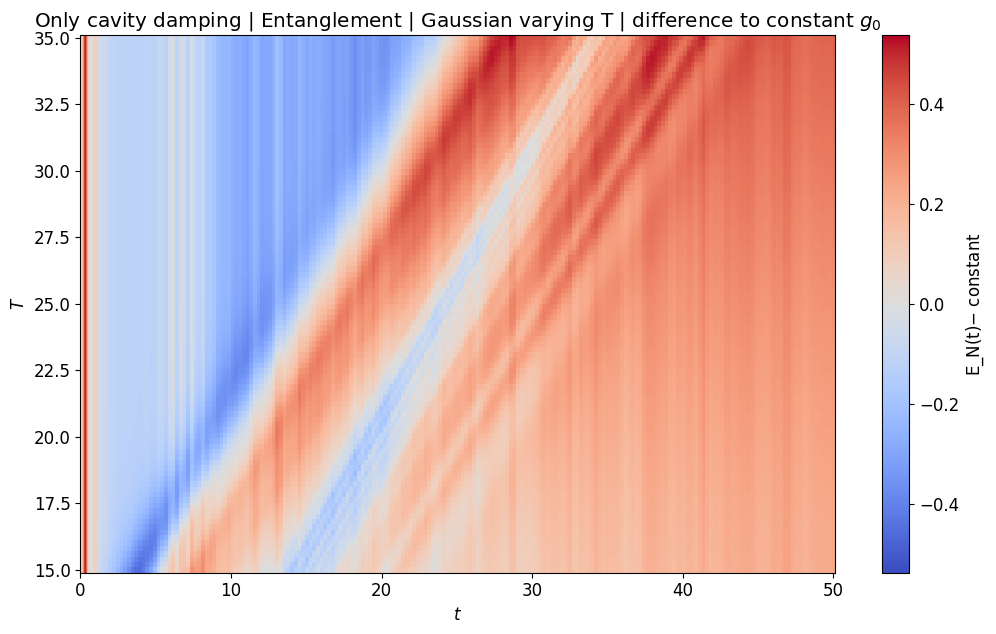

{'case_id': 'only_cavity_damping_entanglement_gauss_T',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_entanglement_gauss_T',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.50000000e-0

In [28]:
plot_surface_case(
    "only_cavity_damping_entanglement_gauss_T",
    title="Only cavity damping | Entanglement | Gaussian varying T",
)

## Cosine varying $\omega$

only_cavity_damping_entanglement_cos_omega
  shape var_aberto = (200, 300)
  t: 0.0 → 50.0 | n = 300
  parameter: 0.0 → 0.6283185307179586 | n = 200


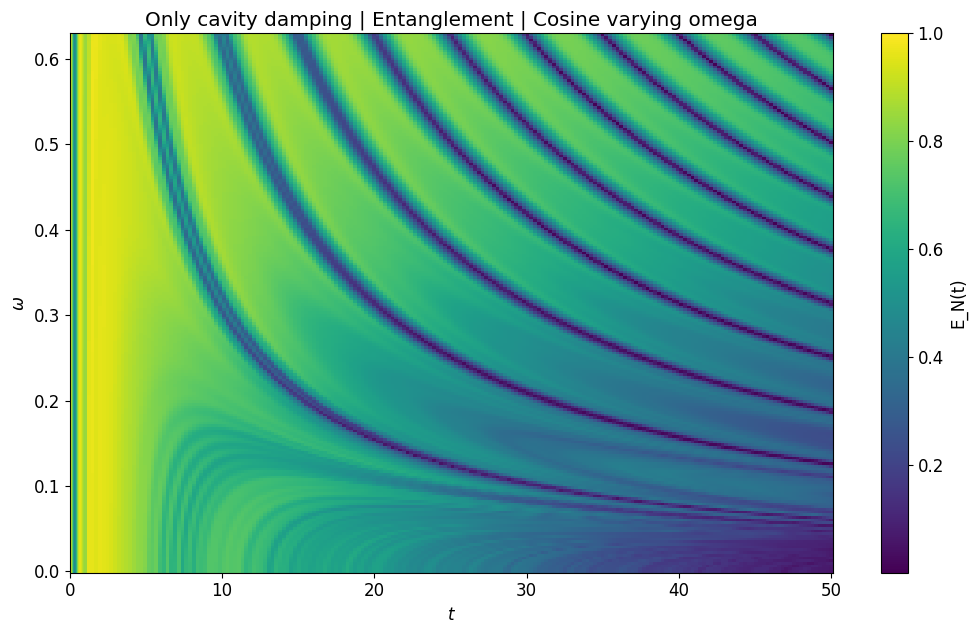

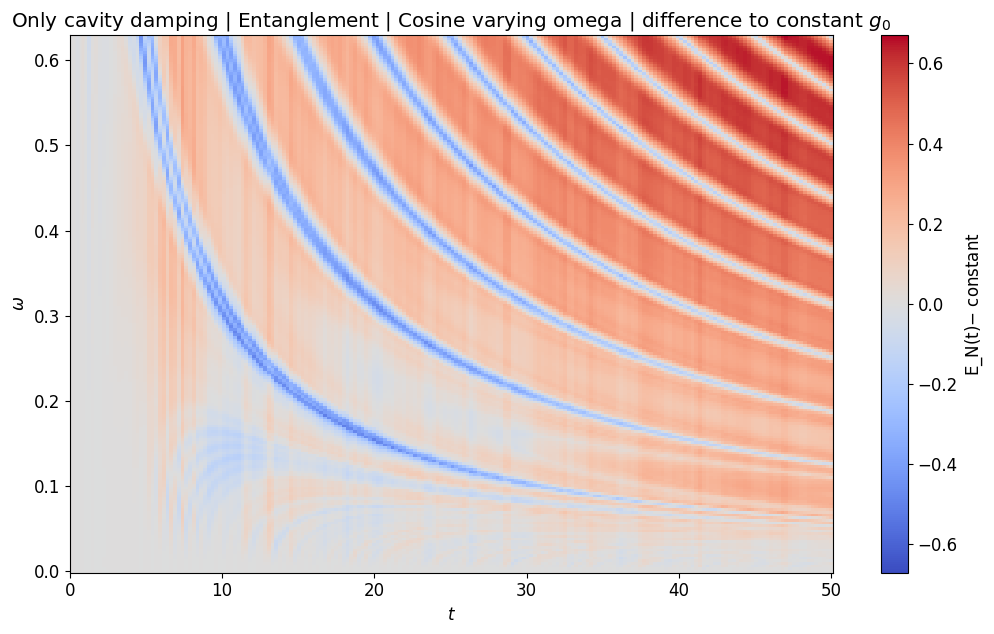

{'case_id': 'only_cavity_damping_entanglement_cos_omega',
 'folder': 'results/lista_simulacoes_open_system/open_system_sims1/only_cavity_damping_entanglement_cos_omega',
 't': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, 3.00000000e-02,
        4.00000000e-02, 5.00000000e-02, 6.00000000e-02, 7.00000000e-02,
        8.00000000e-02, 9.00000000e-02, 1.00000000e-01, 1.10000000e-01,
        1.20000000e-01, 1.30000000e-01, 1.40000000e-01, 1.50000000e-01,
        1.60000000e-01, 1.70000000e-01, 1.80000000e-01, 1.90000000e-01,
        2.00000000e-01, 2.10000000e-01, 2.20000000e-01, 2.30000000e-01,
        2.40000000e-01, 2.50000000e-01, 2.60000000e-01, 2.70000000e-01,
        2.80000000e-01, 2.90000000e-01, 3.00000000e-01, 3.10000000e-01,
        3.20000000e-01, 3.30000000e-01, 3.40000000e-01, 3.50000000e-01,
        3.60000000e-01, 3.70000000e-01, 3.80000000e-01, 3.90000000e-01,
        4.00000000e-01, 4.10000000e-01, 4.20000000e-01, 4.30000000e-01,
        4.40000000e-01, 4.5000000

In [29]:
plot_surface_case(
    "only_cavity_damping_entanglement_cos_omega",
    title="Only cavity damping | Entanglement | Cosine varying omega",
)

# Diagnóstico final

In [30]:
expected_surface_cases = [
    "only_dephasing_wigner_gauss_zeta",
    "only_dephasing_wigner_gauss_T",
    "only_dephasing_wigner_cos_omega",
    "only_dephasing_coherence_gauss_zeta",
    "only_dephasing_coherence_gauss_T",
    "only_dephasing_coherence_cos_omega",
    "only_dephasing_magic_gauss_zeta",
    "only_dephasing_magic_gauss_T",
    "only_dephasing_magic_cos_omega",
    "only_dephasing_entanglement_gauss_zeta",
    "only_dephasing_entanglement_gauss_T",
    "only_dephasing_entanglement_cos_omega",
    "only_cavity_damping_wigner_gauss_zeta",
    "only_cavity_damping_wigner_gauss_T",
    "only_cavity_damping_wigner_cos_omega",
    "only_cavity_damping_coherence_gauss_zeta",
    "only_cavity_damping_coherence_gauss_T",
    "only_cavity_damping_coherence_cos_omega",
    "only_cavity_damping_magic_gauss_zeta",
    "only_cavity_damping_magic_gauss_T",
    "only_cavity_damping_magic_cos_omega",
    "only_cavity_damping_entanglement_gauss_zeta",
    "only_cavity_damping_entanglement_gauss_T",
    "only_cavity_damping_entanglement_cos_omega",
]

rows = []
for case_id in expected_surface_cases:
    folder = case_dir(case_id)
    rows.append({
        "case_id": case_id,
        "folder_exists": os.path.isdir(folder),
        "t.npy": os.path.exists(os.path.join(folder, "t.npy")),
        "scan_values.npy": os.path.exists(os.path.join(folder, "scan_values.npy")),
        "var_aberto.npy": os.path.exists(os.path.join(folder, "var_aberto.npy")),
        "const_aberto.npy": os.path.exists(os.path.join(folder, "const_aberto.npy")),
        "DONE.txt": os.path.exists(os.path.join(folder, "DONE.txt")),
    })

diagnostic = pd.DataFrame(rows)
display(diagnostic)
print("Casos completos:", int((diagnostic[["folder_exists", "t.npy", "scan_values.npy", "var_aberto.npy"]].all(axis=1)).sum()), "/", len(diagnostic))
print("Figuras salvas em:", FIG_DIR)

,case_id,folder_exists,t.npy,scan_values.npy,var_aberto.npy,const_aberto.npy,DONE.txt
0,only_dephasing_wigner_gauss_zeta,True,True,True,True,True,True
1,only_dephasing_wigner_gauss_T,True,True,True,True,True,True
2,only_dephasing_wigner_cos_omega,True,True,True,True,True,True
3,only_dephasing_coherence_gauss_zeta,True,True,True,True,True,True
4,only_dephasing_coherence_gauss_T,True,True,True,True,True,True
5,only_dephasing_coherence_cos_omega,True,True,True,True,True,True
6,only_dephasing_magic_gauss_zeta,True,True,True,True,True,True
7,only_dephasing_magic_gauss_T,True,True,True,True,True,True
8,only_dephasing_magic_cos_omega,True,True,True,True,True,True
9,only_dephasing_entanglement_gauss_zeta,True,True,True,True,True,True


Casos completos: 24 / 24
Figuras salvas em: results/lista_simulacoes_open_system/open_system_sims1/figures_surfaces_parameter_time
